In [1]:
import os
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import gffutils
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
# Simplified sequence-based validation of conserved splice junctions
from Bio import pairwise2
from Bio.Seq import Seq
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# Create directory with today's date
today = datetime.now().strftime('%Y-%m-%d')
output_dir = f'plots_{today}'
os.makedirs(output_dir, exist_ok=True)
print(f"Created directory: {output_dir}")

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *

from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from pyfaidx import Fasta
from Bio.Seq import Seq

# reload atseviz code 
# reload atse_viz code 
import importlib
import atse_viz  # Make sure it's already been imported
importlib.reload(atse_viz)
from atse_viz import *  # Re-import symbols if needed

# Load genome
human_genome = Fasta("/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/GRCh38.primary_assembly.genome.fa")
mouse_genome = Fasta("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/fasta/genome.fa")

# Load data first
MOUSE = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
HUMAN = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/TMS_atse_file_unanno_also_2025-07-31_08-10-26.txt.gz"

print("Loading data...")
mouse_atse = pd.read_csv(MOUSE, sep="\t")
human_atse = pd.read_csv(HUMAN, sep="\t")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Created directory: plots_2025-08-07
Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!
Visualization imports successful!
Loading data...


In [2]:
mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

human_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/v45hg38"
db_human = gffutils.FeatureDB(human_db_file, keep_order=True)

orthos = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz", sep="\t")

# Process ortholog data
print("Processing ortholog data...")
o_genes = orthos[["Gene stable ID", "Mouse gene stable ID", "Last common ancestor with Mouse", 
                  "Mouse homology type", "Mouse gene name", "Gene name"]].drop_duplicates()
o_genes = o_genes[o_genes["Mouse homology type"].isin(["ortholog_one2one"])]

# Clean gene IDs
mouse_atse["gene_id"] = mouse_atse["gene_id"].str.split(".").str[0]
human_atse["gene_id"] = human_atse["gene_id"].str.split(".").str[0]

# Prepare for merging
mouse_atse["Mouse gene stable ID"] = mouse_atse["gene_id"]
human_atse["Gene stable ID"] = human_atse["gene_id"]
mouse_atse["Mouse gene name"] = mouse_atse["gene_name"]
human_atse["Gene name"] = human_atse["gene_name"]

/scratch/ipykernel_487965/550233970.py:7: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  orthos = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz", sep="\t")


Processing ortholog data...


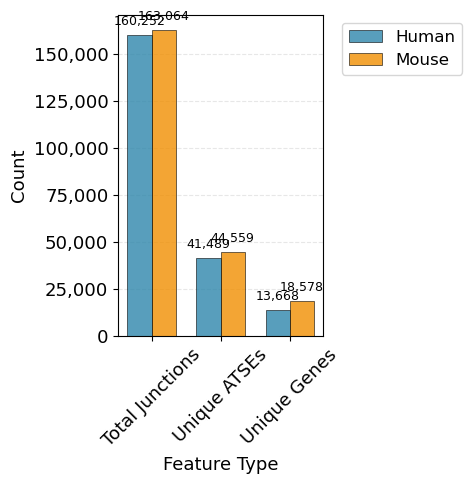

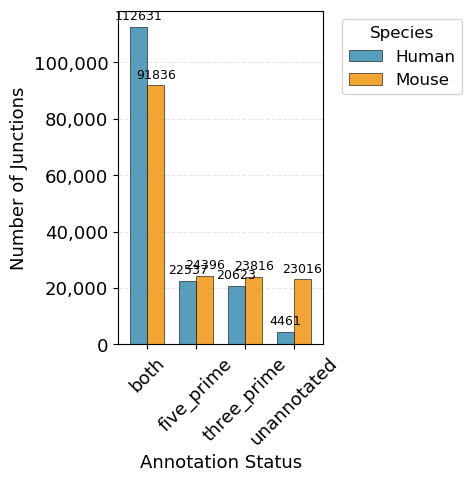

Plots saved in directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper
Files saved:
  - /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/overview_barplot.pdf
  - /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/annotation_status_barplot.pdf


In [3]:
plot_dir = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper"

# Add species column
human_atse['species'] = 'Human'
mouse_atse['species'] = 'Mouse'

# Combine datasets
combined_df = pd.concat([human_atse, mouse_atse], ignore_index=True)

# Set publication-ready style
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12
})

# Define publication colors
colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
ann_colors = ['#E63946', '#457B9D', '#F1C40F', '#2ECC71']  # Red, Blue, Yellow, Green

# 1. MAIN OVERVIEW BARPLOT - FLIPPED TO SHOW CATEGORIES ON X-AXIS, COLORED BY SPECIES
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Prepare data for overview plot
overview_data = []
for species in ['Human', 'Mouse']:
    data = combined_df[combined_df['species'] == species]
    overview_data.append({
        'Species': species,
        'Total Junctions': data['junction_id'].nunique(),
        'Unique ATSEs': data['event_id'].nunique(),
        'Unique Genes': data['gene_id'].nunique()
    })

overview_df = pd.DataFrame(overview_data)

# Create grouped bar plot with categories on x-axis
categories = ['Total Junctions', 'Unique ATSEs', 'Unique Genes']
x = np.arange(len(categories))
width = 0.35

# Extract values for each species
human_values = [overview_df[overview_df['Species'] == 'Human'][cat].values[0] for cat in categories]
mouse_values = [overview_df[overview_df['Species'] == 'Mouse'][cat].values[0] for cat in categories]

bars1 = ax.bar(x - width/2, human_values, width,
               label='Human', color=colors[0], alpha=0.8,
               edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, mouse_values, width,
               label='Mouse', color=colors[2], alpha=0.8,
               edgecolor='black', linewidth=0.5)

ax.set_xlabel('Feature Type')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(categories)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Move legend outside the plot
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Format y-axis with comma separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add value labels with smaller font
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height):,}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 5),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
# Save as PDF
plt.savefig(os.path.join(plot_dir, 'overview_barplot.pdf'), format='pdf', bbox_inches='tight')
plt.show()

# 2. JUNCTIONS BY ANNOTATION STATUS - FLIPPED TO SHOW ANNOTATION STATUS ON X-AXIS, COLORED BY SPECIES
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Group by annotation status and species
ann_summary = combined_df.groupby(['annotation_status', 'species'])['junction_id'].nunique().unstack(fill_value=0)

# Plot with annotation status on x-axis, colored by species
bars = ann_summary.plot(kind='bar', ax=ax, width=0.7, color=[colors[0], colors[2]],
                        alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Annotation Status')
ax.set_ylabel('Number of Junctions')

# Move legend outside the plot
ax.legend(title='Species', title_fontsize=12,
          bbox_to_anchor=(1.05, 1), loc='upper left',
          frameon=True)

# Format y-axis with comma separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

plt.xticks(rotation=45)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()

# Save as PDF
plt.savefig(os.path.join(plot_dir, 'annotation_status_barplot.pdf'), format='pdf', bbox_inches='tight')
plt.show()

print(f"Plots saved in directory: {plot_dir}")
print(f"Files saved:")
print(f"  - {os.path.join(plot_dir, 'overview_barplot.pdf')}")
print(f"  - {os.path.join(plot_dir, 'annotation_status_barplot.pdf')}")

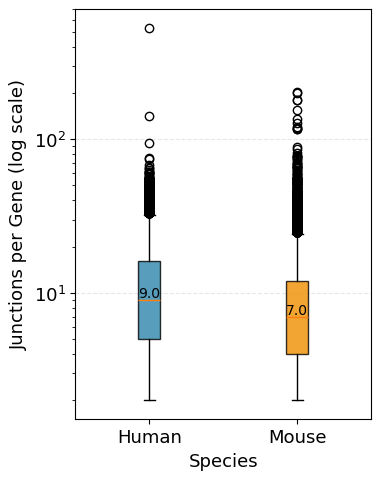

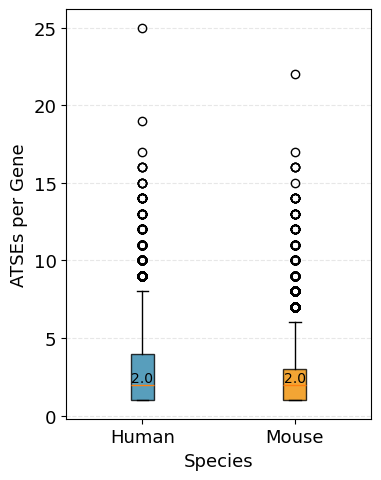

=== SUMMARY STATISTICS ===

Junctions per Gene:
Human: Mean = 11.72, Median = 9.00
Mouse: Mean = 8.78, Median = 7.00

ATSEs per Gene:
Human: Mean = 3.04, Median = 2.00
Mouse: Mean = 2.40, Median = 2.00


In [4]:
# 3. JUNCTIONS PER GENE DISTRIBUTION
fig, ax = plt.subplots(1, 1, figsize=(4, 5))

# Calculate junctions per gene for each species
junction_data = {}
for species in ['Human', 'Mouse']:
    data = combined_df[combined_df['species'] == species]
    junctions_per_gene = data.groupby('gene_id')['junction_id'].nunique()
    junction_data[species] = junctions_per_gene.values

# Box plot
junction_data_list = [junction_data['Human'], junction_data['Mouse']]
box_plot = ax.boxplot(junction_data_list, labels=['Human', 'Mouse'], patch_artist=True)

# Color the box plots - using blue for Human, orange for Mouse
for patch, color in zip(box_plot['boxes'], [colors[0], colors[2]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Add simple median values on top
for i, species in enumerate(['Human', 'Mouse']):
    median_val = np.median(junction_data[species])
    ax.text(i+1, median_val, f'{median_val:.1f}',
            ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Species')
ax.set_ylabel('Junctions per Gene (log scale)')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
# Save as PDF
plt.savefig(os.path.join(output_dir, 'junctions_per_gene_distribution.pdf'), format='pdf', bbox_inches='tight')
plt.show()

# 4. ATSEs PER GENE DISTRIBUTION
fig, ax = plt.subplots(1, 1, figsize=(4, 5))

# Calculate ATSEs per gene for each species
atse_data = {}
for species in ['Human', 'Mouse']:
    data = combined_df[combined_df['species'] == species]
    atses_per_gene = data.groupby('gene_id')['event_id'].nunique()
    atse_data[species] = atses_per_gene.values

# Box plot
atse_data_list = [atse_data['Human'], atse_data['Mouse']]
box_plot = ax.boxplot(atse_data_list, labels=['Human', 'Mouse'], patch_artist=True)

# Color the box plots - using blue for Human, orange for Mouse
for patch, color in zip(box_plot['boxes'], [colors[0], colors[2]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Add simple median values on top
for i, species in enumerate(['Human', 'Mouse']):
    median_val = np.median(atse_data[species])
    ax.text(i+1, median_val, f'{median_val:.1f}',
            ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Species')
ax.set_ylabel('ATSEs per Gene')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
# Save as PDF
plt.savefig(os.path.join(output_dir, 'atses_per_gene_distribution.pdf'), format='pdf', bbox_inches='tight')
plt.show()

# Print summary statistics
print("=== SUMMARY STATISTICS ===")
print("\nJunctions per Gene:")
for species in ['Human', 'Mouse']:
    data = junction_data[species]
    print(f"{species}: Mean = {data.mean():.2f}, Median = {np.median(data):.2f}")

print("\nATSEs per Gene:")
for species in ['Human', 'Mouse']:
    data = atse_data[species]
    print(f"{species}: Mean = {data.mean():.2f}, Median = {np.median(data):.2f}")

In [5]:
# Print initial data sizes
print("=== INITIAL DATA SIZES ===")
print(f"Human junctions before ortholog merge: {len(human_atse):,}")
print(f"Mouse junctions before ortholog merge: {len(mouse_atse):,}")
print(f"Human unique ATSEs before merge: {human_atse['event_id'].nunique():,}")
print(f"Mouse unique ATSEs before merge: {mouse_atse['event_id'].nunique():,}")
print(f"Ortholog genes data: {len(o_genes):,}")

# Merge with ortholog data
mouse_atse = mouse_atse.merge(o_genes, on=["Mouse gene stable ID", "Mouse gene name"])
human_atse = human_atse.merge(o_genes, on=["Gene stable ID"])

print("\n=== AFTER ORTHOLOG MERGE ===")
print(f"Human junctions after ortholog merge: {len(human_atse):,}")
print(f"Mouse junctions after ortholog merge: {len(mouse_atse):,}")
print(f"Human unique ATSEs after merge: {human_atse['event_id'].nunique():,}")
print(f"Mouse unique ATSEs after merge: {mouse_atse['event_id'].nunique():,}")

# Get unique gene counts before filtering for shared genes
human_genes_before = human_atse["Gene stable ID"].nunique()
mouse_genes_before = mouse_atse["Mouse gene stable ID"].nunique()
print(f"Human unique genes: {human_genes_before:,}")
print(f"Mouse unique genes: {mouse_genes_before:,}")

# Filter for shared genes
human_atse = human_atse[human_atse["Mouse gene stable ID"].isin(mouse_atse["Mouse gene stable ID"])]
mouse_atse = mouse_atse[mouse_atse["Gene stable ID"].isin(human_atse["Gene stable ID"])]

print("\n=== AFTER FILTERING FOR SHARED GENES ACROSS SPECIES ===")
print(f"Human junctions with shared genes: {len(human_atse):,}")
print(f"Mouse junctions with shared genes: {len(mouse_atse):,}")
print(f"Human unique ATSEs with shared genes: {human_atse['event_id'].nunique():,}")
print(f"Mouse unique ATSEs with shared genes: {mouse_atse['event_id'].nunique():,}")

# Get shared gene counts
shared_human_genes = human_atse["Gene stable ID"].nunique()
shared_mouse_genes = mouse_atse["Mouse gene stable ID"].nunique()
print(f"Shared genes (Human perspective): {shared_human_genes:,}")
print(f"Shared genes (Mouse perspective): {shared_mouse_genes:,}")

human_atse_ortho_full = human_atse.copy()
mouse_atse_ortho_full = mouse_atse.copy()

# Apply filters (NOTE: ONLY KEEPING ATSES WITH 3 JUNCTIONS OR LESS)
# For now, to just try and find conserved simple exon skipping or alt 5'/3' splicing
num_junctions_filter = 3

print(f"\n=== APPLYING JUNCTION FILTER (≤{num_junctions_filter}) ===")
human_before_junction_filter = len(human_atse)
mouse_before_junction_filter = len(mouse_atse)
human_atses_before_junction_filter = human_atse['event_id'].nunique()
mouse_atses_before_junction_filter = mouse_atse['event_id'].nunique()

human_atse = human_atse[human_atse["num_junctions"] <= 5]
mouse_atse = mouse_atse[mouse_atse["num_junctions"] <= 5]

print(f"Human junctions after junction filter: {len(human_atse):,} (lost {human_before_junction_filter - len(human_atse):,})")
print(f"Mouse junctions after junction filter: {len(mouse_atse):,} (lost {mouse_before_junction_filter - len(mouse_atse):,})")
print(f"Human ATSEs after junction filter: {human_atse['event_id'].nunique():,} (lost {human_atses_before_junction_filter - human_atse['event_id'].nunique():,})")
print(f"Mouse ATSEs after junction filter: {mouse_atse['event_id'].nunique():,} (lost {mouse_atses_before_junction_filter - mouse_atse['event_id'].nunique():,})")

print(f"\n=== APPLYING ONE-TO-ONE ORTHOLOG FILTER ===")
human_before_ortho_filter = len(human_atse)
mouse_before_ortho_filter = len(mouse_atse)
human_atses_before_ortho_filter = human_atse['event_id'].nunique()
mouse_atses_before_ortho_filter = mouse_atse['event_id'].nunique()

human_atse = human_atse[human_atse["Mouse homology type"] == "ortholog_one2one"]
mouse_atse = mouse_atse[mouse_atse["Mouse homology type"] == "ortholog_one2one"]

print(f"Human junctions after one-to-one ortholog filter: {len(human_atse):,} (lost {human_before_ortho_filter - len(human_atse):,})")
print(f"Mouse junctions after one-to-one ortholog filter: {len(mouse_atse):,} (lost {mouse_before_ortho_filter - len(mouse_atse):,})")
print(f"Human ATSEs after one-to-one ortholog filter: {human_atse['event_id'].nunique():,} (lost {human_atses_before_ortho_filter - human_atse['event_id'].nunique():,})")
print(f"Mouse ATSEs after one-to-one ortholog filter: {mouse_atse['event_id'].nunique():,} (lost {mouse_atses_before_ortho_filter - mouse_atse['event_id'].nunique():,})")

print(f"\n=== REMOVING GENES WITH MULTIPLE STRANDS ===")
# Remove genes with multiple strands from human dataset
gene_strand_info = human_atse.groupby('gene_id')['strand'].nunique().reset_index()
genes_with_multiple_strands = gene_strand_info[gene_strand_info['strand'] > 1]

print(f"Genes with multiple strands in human data: {len(genes_with_multiple_strands):,}")

human_before_strand_filter = len(human_atse)
human_atses_before_strand_filter = human_atse['event_id'].nunique()
human_genes_before_strand_filter = human_atse['gene_id'].nunique()

human_atse = human_atse[~human_atse["gene_id"].isin(genes_with_multiple_strands["gene_id"])]

print(f"Human junctions after removing multi-strand genes: {len(human_atse):,} (lost {human_before_strand_filter - len(human_atse):,})")
print(f"Human ATSEs after removing multi-strand genes: {human_atse['event_id'].nunique():,} (lost {human_atses_before_strand_filter - human_atse['event_id'].nunique():,})")
print(f"Human genes after removing multi-strand genes: {human_atse['gene_id'].nunique():,} (lost {human_genes_before_strand_filter - human_atse['gene_id'].nunique():,})")

print(f"\n=== FINAL SHARED GENE FILTERING ===")
human_before_final_filter = len(human_atse)
mouse_before_final_filter = len(mouse_atse)
human_atses_before_final_filter = human_atse['event_id'].nunique()
mouse_atses_before_final_filter = mouse_atse['event_id'].nunique()

# Final filtering for shared genes after strand filtering
human_atse = human_atse[human_atse["Mouse gene stable ID"].isin(mouse_atse["Mouse gene stable ID"])]
mouse_atse = mouse_atse[mouse_atse["Mouse gene stable ID"].isin(human_atse["Mouse gene stable ID"])]

print(f"Human junctions after final shared gene filter: {len(human_atse):,} (lost {human_before_final_filter - len(human_atse):,})")
print(f"Mouse junctions after final shared gene filter: {len(mouse_atse):,} (lost {mouse_before_final_filter - len(mouse_atse):,})")
print(f"Human ATSEs after final shared gene filter: {human_atse['event_id'].nunique():,} (lost {human_atses_before_final_filter - human_atse['event_id'].nunique():,})")
print(f"Mouse ATSEs after final shared gene filter: {mouse_atse['event_id'].nunique():,} (lost {mouse_atses_before_final_filter - mouse_atse['event_id'].nunique():,})")

# Calculate shared orthologous genes
shared_genes = set(mouse_atse['Mouse gene name']).intersection(
    set(human_atse['Mouse gene name'])
)

print(f"\nShared orthologous genes: {len(shared_genes):,}")

# Save as final set of shared genes between species
shared_genes = shared_genes.copy()

=== INITIAL DATA SIZES ===
Human junctions before ortholog merge: 160,252
Mouse junctions before ortholog merge: 163,064
Human unique ATSEs before merge: 41,489
Mouse unique ATSEs before merge: 44,559
Ortholog genes data: 17,137

=== AFTER ORTHOLOG MERGE ===
Human junctions after ortholog merge: 139,271
Mouse junctions after ortholog merge: 117,821
Human unique ATSEs after merge: 36,903
Mouse unique ATSEs after merge: 34,165
Human unique genes: 11,396
Mouse unique genes: 12,564

=== AFTER FILTERING FOR SHARED GENES ACROSS SPECIES ===
Human junctions with shared genes: 126,807
Mouse junctions with shared genes: 96,947
Human unique ATSEs with shared genes: 33,376
Mouse unique ATSEs with shared genes: 28,022
Shared genes (Human perspective): 9,877
Shared genes (Mouse perspective): 9,877

=== APPLYING JUNCTION FILTER (≤3) ===
Human junctions after junction filter: 82,283 (lost 44,524)
Mouse junctions after junction filter: 68,569 (lost 28,378)
Human ATSEs after junction filter: 28,324 (los

In [6]:
output_dir

'plots_2025-08-07'

In [7]:
# Create subdirectories
subdirs = ["data", "figures", "results"]

print(f"Creating analysis directory: {output_dir}")
os.makedirs(output_dir, exist_ok=True)

for subdir in subdirs:
    subdir_path = os.path.join(output_dir, subdir)
    os.makedirs(subdir_path, exist_ok=True)
    print(f"Created: {subdir_path}")

# Define paths for easy access
paths = {
    'base': output_dir,
    'data': os.path.join(output_dir, "data"),
    'figures': os.path.join(output_dir, "figures"),
    'results': os.path.join(output_dir, "results")
}

# Create README with correct variables
readme_content = f"""# Cross-Species Splicing Conservation Analysis

## Directory Structure:
- data/: Processed datasets (filtered ATSE files, ortholog mappings, etc.)
- figures/: All plots and visualizations
- results/: Analysis results, conservation tables, summary statistics

## Data Sources:
- Mouse ATSE: {MOUSE}
- Human ATSE: {HUMAN}
- Orthologs: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz

## Analysis Goals:
1. Compare splice motif usage between mouse and human
2. Analyze junction count distributions
3. Identify conserved splice junctions in one-to-one orthologs
4. Cross-species aging factor conservation analysis

## Key Statistics:
- Shared orthologous genes: {len(shared_genes)}
- Mouse junctions: {len(mouse_atse)}
- Human junctions: {len(human_atse)}
- Mouse genes: {mouse_atse['gene_id'].nunique()}
- Human genes: {human_atse['gene_id'].nunique()}
"""

with open(os.path.join(output_dir, "README.md"), "w") as f:
    f.write(readme_content)

print(f"\nAnalysis folder created successfully!")
print(f"Base directory: {output_dir}")


# Helper function to save figures
def save_figure(fig_name, description=""):
    """Helper function to save figures with timestamp."""
    timestamp = datetime.now().strftime("%H%M%S")
    filename = f"{timestamp}_{fig_name}"
    
    # Save as PDF
    pdf_path = os.path.join(paths['figures'], f"{filename}.pdf")
    plt.savefig(pdf_path, dpi=300, bbox_inches='tight')
    
    # Save as PNG
    png_path = os.path.join(paths['figures'], f"{filename}.png")
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    
    print(f"Figure saved: {filename}")
    return pdf_path

Creating analysis directory: plots_2025-08-07
Created: plots_2025-08-07/data
Created: plots_2025-08-07/figures
Created: plots_2025-08-07/results

Analysis folder created successfully!
Base directory: plots_2025-08-07



Creating plots...
Figure saved: 003718_splice_motif_usage_comparison


'plots_2025-08-07/figures/003718_splice_motif_usage_comparison.pdf'

<Figure size 400x400 with 0 Axes>

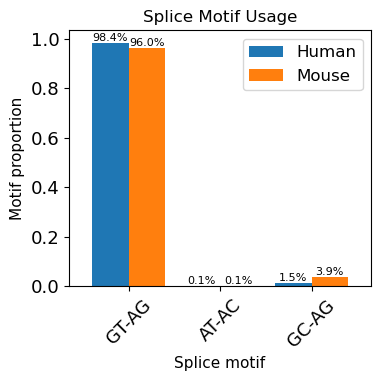

In [8]:
print("\nCreating plots...")

# 1. Splice motif usage
human_motifs = Counter(human_atse["splice_motif"])
mouse_motifs = Counter(mouse_atse["splice_motif"])
motif_df = pd.DataFrame([human_motifs, mouse_motifs], index=["Human", "Mouse"]).fillna(0)
motif_df_prop = motif_df.div(motif_df.sum(axis=1), axis=0)

plt.figure(figsize=(4, 4))
ax = motif_df_prop.T.plot(kind="bar", figsize=(4, 4), width=0.8)
ax.set_ylabel("Motif proportion", fontsize=11)
ax.set_xlabel("Splice motif", fontsize=11)
ax.set_title("Splice Motif Usage", fontsize=12)
plt.xticks(rotation=45)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f"{height*100:.1f}%", 
                        (bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
save_figure("splice_motif_usage_comparison")
#plt.close()


Figure saved: 003723_donor_acceptor_read_distributions


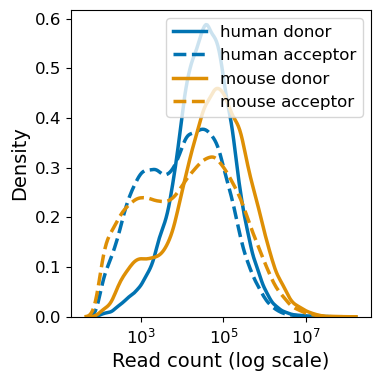

In [9]:
# 1. Set a color palette and define visual properties
palette = sns.color_palette("colorblind", 2)
human_color = palette[0]
mouse_color = palette[1]

donor_style = "-"  # Solid line
acceptor_style = "--" # Dashed line

# 2. Plotting
plt.figure(figsize=(4, 4)) # Increased figure size for better readability

# Plot Human data
sns.kdeplot(human_atse["donor_total_reads"],
            label="human donor",
            log_scale=True,
            color=human_color,
            linestyle=donor_style,
            linewidth=2.5)
sns.kdeplot(human_atse["acceptor_total_reads"],
            label="human acceptor",
            log_scale=True,
            color=human_color,
            linestyle=acceptor_style,
            linewidth=2.5)

# Plot Mouse data
sns.kdeplot(mouse_atse["donor_total_reads"],
            label="mouse donor",
            log_scale=True,
            color=mouse_color,
            linestyle=donor_style,
            linewidth=2.5)
sns.kdeplot(mouse_atse["acceptor_total_reads"],
            label="mouse acceptor",
            log_scale=True,
            color=mouse_color,
            linestyle=acceptor_style,
            linewidth=2.5)


# 3. Increase font sizes for readability
plt.xlabel("Read count (log scale)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=12)

# Adjust tick label sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout() # Adjusts plot to prevent labels from overlapping

# 4. Save and show the figure
save_figure("donor_acceptor_read_distributions", "Log-scale KDE plots of read counts")
plt.show()

Figure saved: 003725_junction_count_per_gene_annotated


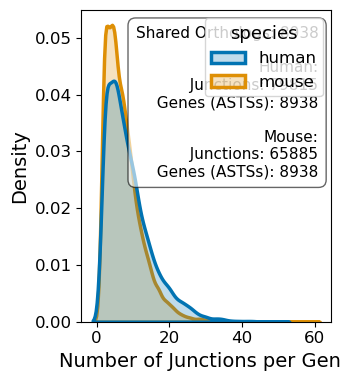


Analysis setup complete!
Summary statistics saved to: plots_2025-08-07/results/summary_statistics.csv

Path variables for future use:
  base_dir = 'plots_2025-08-07'
  data_dir = 'plots_2025-08-07/data'
  figures_dir = 'plots_2025-08-07/figures'
  results_dir = 'plots_2025-08-07/results'


In [10]:
# 3. Junction count per gene
human_counts = human_atse["gene_id"].value_counts()
mouse_counts = mouse_atse["gene_id"].value_counts()

human_df = human_counts.to_frame(name="junction_count").reset_index()
human_df["species"] = "human"
mouse_df = mouse_counts.to_frame(name="junction_count").reset_index()
mouse_df["species"] = "mouse"
combined_df = pd.concat([human_df, mouse_df], ignore_index=True)

# 1. Prepare statistics for annotation
# Assuming 'ASTSSes' refers to the total number of unique genes with junctions
human_genes_total = human_atse['gene_id'].nunique()
mouse_genes_total = mouse_atse['gene_id'].nunique()
human_junctions_total = len(human_atse)
mouse_junctions_total = len(mouse_atse)
shared_orthologs_count = len(shared_genes)

# Format the text for the plot
stats_text = (
    f"Shared Orthologs: {shared_orthologs_count}\n\n"
    f"Human:\n"
    f"  Junctions: {human_junctions_total}\n"
    f"  Genes (ASTSs): {human_genes_total}\n\n"
    f"Mouse:\n"
    f"  Junctions: {mouse_junctions_total}\n"
    f"  Genes (ASTSs): {mouse_genes_total}"
)

# 2. Create the visualization
plt.figure(figsize=(4, 4))
sns.set_palette("colorblind") # Use a publication-friendly palette
sns.kdeplot(data=combined_df, x="junction_count", hue="species", fill=True, linewidth=2.5)

# 3. Add larger fonts and annotation box
plt.xlabel("Number of Junctions per Gene", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add the text box with statistics
plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes, # Position relative to the axes
         fontsize=11,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.6))

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for text
save_figure("junction_count_per_gene_annotated", "Distribution of junction counts with summary stats")
plt.show()

## Save summary statistics (no changes needed here)

summary_stats = {
    'shared_orthologous_genes': shared_orthologs_count,
    'mouse_junctions_total': mouse_junctions_total,
    'human_junctions_total': human_junctions_total,
    'mouse_genes_total': mouse_genes_total,
    'human_genes_total': human_genes_total
}

summary_df = pd.Series(summary_stats, name="value")
summary_df.index.name = "statistic"
summary_df.to_csv(os.path.join(paths['results'], "summary_statistics.csv"))

print(f"\nAnalysis setup complete!")
print(f"Summary statistics saved to: {os.path.join(paths['results'], 'summary_statistics.csv')}")

# Print the paths for reference
print("\nPath variables for future use:")
for key, path in paths.items():
    print(f"  {key}_dir = '{path}'")

In [11]:
def parse_junction_id(junction_id):
    """Parse junction ID to extract coordinates."""
    parts = junction_id.split('_')
    chrom, start, end, strand = parts[0], int(parts[1]), int(parts[2]), parts[3]
    return chrom, start, end, strand

def create_mouse_junction_bed(mouse_atse_df, output_dir):
    """
    Create BED file for mouse junction coordinates.
    
    Args:
        mouse_atse_df: Mouse ATSE dataframe
        output_dir: Directory to save BED files
    
    Returns:
        Path to created BED file
    """
    
    print(f"Creating mouse junction BED file from {len(mouse_atse_df)} junctions...")
    
    bed_entries = []
    
    for idx, row in mouse_atse_df.iterrows():
        try:
            chrom, start, end, strand = parse_junction_id(row['junction_id'])
            
            # Create BED entry for the full junction
            # BED format: chrom, start, end, name, score, strand
            bed_entries.append({
                'chrom': chrom,
                'start': start,  # BED is 0-based, but junction coordinates are usually 1-based
                'end': end,
                'name': f"{row['junction_id']}_{row['gene_name']}_{row['event_id']}",
                'score': 0,
                'strand': strand,
                'junction_id': row['junction_id'],
                'gene_name': row['gene_name'],
                'event_id': row['event_id'],
                'gene_id': row['gene_id']
            })
            
        except Exception as e:
            print(f"Error parsing junction {row['junction_id']}: {e}")
            continue
    
    # Create DataFrame and save as BED
    bed_df = pd.DataFrame(bed_entries)
    
    # Sort by chromosome and position
    bed_df = bed_df.sort_values(['chrom', 'start'])
    
    # Create BED file (standard 6-column format for UCSC)
    bed_file_path = os.path.join(output_dir, "mouse_junctions_mm10.bed")
    
    # Write BED file (tab-separated, no header)
    with open(bed_file_path, 'w') as f:
        for _, row in bed_df.iterrows():
            f.write(f"{row['chrom']}\t{row['start']}\t{row['end']}\t{row['name']}\t{row['score']}\t{row['strand']}\n")
    
    # Also save the full annotation file for later matching
    annotation_file_path = os.path.join(output_dir, "mouse_junctions_annotations.csv")
    bed_df.to_csv(annotation_file_path, index=False)
    
    print(f"Mouse BED file created: {bed_file_path}")
    print(f"Mouse annotations saved: {annotation_file_path}")
    print(f"   Contains {len(bed_df)} junctions from {bed_df['gene_name'].nunique()} genes")
    
    return bed_file_path, annotation_file_path

def create_human_junction_bed(human_atse_df, output_dir):
    """
    Create BED file for human junction coordinates.
    
    Args:
        human_atse_df: Human ATSE dataframe
        output_dir: Directory to save BED files
    
    Returns:
        Path to created BED file
    """
    
    print(f"Creating human junction BED file from {len(human_atse_df)} junctions...")
    
    bed_entries = []
    
    for idx, row in human_atse_df.iterrows():
        try:
            chrom, start, end, strand = parse_junction_id(row['junction_id'])
            
            # Create BED entry for the full junction
            bed_entries.append({
                'chrom': chrom,
                'start': start,
                'end': end,
                'name': f"{row['junction_id']}_{row.get('Gene name', 'Unknown')}_{row['event_id']}",
                'score': 0,
                'strand': strand,
                'junction_id': row['junction_id'],
                'human_gene_name': row.get('Gene name', 'Unknown'),
                'mouse_gene_name': row.get('Mouse gene name', 'Unknown'),
                'event_id': row['event_id'],
                'gene_id': row['gene_id']
            })
            
        except Exception as e:
            print(f"Error parsing junction {row['junction_id']}: {e}")
            continue
    
    # Create DataFrame and save as BED
    bed_df = pd.DataFrame(bed_entries)
    
    # Sort by chromosome and position
    bed_df = bed_df.sort_values(['chrom', 'start'])
    
    # Create BED file
    bed_file_path = os.path.join(output_dir, "human_junctions_hg38.bed")
    
    # Write BED file (tab-separated, no header)
    with open(bed_file_path, 'w') as f:
        for _, row in bed_df.iterrows():
            f.write(f"{row['chrom']}\t{row['start']}\t{row['end']}\t{row['name']}\t{row['score']}\t{row['strand']}\n")
    
    # Also save the full annotation file
    annotation_file_path = os.path.join(output_dir, "human_junctions_annotations.csv")
    bed_df.to_csv(annotation_file_path, index=False)
    
    print(f"Human BED file created: {bed_file_path}")
    print(f"Human annotations saved: {annotation_file_path}")
    print(f"   Contains {len(bed_df)} junctions from {bed_df['human_gene_name'].nunique()} human genes")
    
    return bed_file_path, annotation_file_path

def create_donor_acceptor_bed_files(atse_df, species, output_dir):
    """
    Create separate BED files for donor and acceptor sites.
    This might be useful for more precise liftover.
    
    Args:
        atse_df: ATSE dataframe
        species: "mouse" or "human"
        output_dir: Directory to save BED files
    """
    
    print(f"Creating {species} donor/acceptor BED files...")
    
    donor_entries = []
    acceptor_entries = []
    
    for idx, row in atse_df.iterrows():
        try:
            chrom, start, end, strand = parse_junction_id(row['junction_id'])
            
            gene_name = row['gene_name'] if species == 'mouse' else row.get('Gene name', 'Unknown')
            
            # Donor site (junction start)
            donor_entries.append({
                'chrom': chrom,
                'start': start - 1,  # Make it a single base position
                'end': start,
                'name': f"{row['junction_id']}_donor_{gene_name}",
                'score': 0,
                'strand': strand,
                'site_type': 'donor',
                'junction_id': row['junction_id'],
                'gene_name': gene_name,
                'event_id': row['event_id']
            })
            
            # Acceptor site (junction end)
            acceptor_entries.append({
                'chrom': chrom,
                'start': end - 1,  # Make it a single base position
                'end': end,
                'name': f"{row['junction_id']}_acceptor_{gene_name}",
                'score': 0,
                'strand': strand,
                'site_type': 'acceptor',
                'junction_id': row['junction_id'],
                'gene_name': gene_name,
                'event_id': row['event_id']
            })
            
        except Exception as e:
            print(f"Error parsing junction {row['junction_id']}: {e}")
            continue
    
    # Create DataFrames
    donor_df = pd.DataFrame(donor_entries).sort_values(['chrom', 'start'])
    acceptor_df = pd.DataFrame(acceptor_entries).sort_values(['chrom', 'start'])
    
    # Save donor BED file
    genome_build = "mm10" if species == "mouse" else "hg38"
    donor_bed_path = os.path.join(output_dir, f"{species}_donor_sites_{genome_build}.bed")
    acceptor_bed_path = os.path.join(output_dir, f"{species}_acceptor_sites_{genome_build}.bed")
    
    # Write donor BED
    with open(donor_bed_path, 'w') as f:
        for _, row in donor_df.iterrows():
            f.write(f"{row['chrom']}\t{row['start']}\t{row['end']}\t{row['name']}\t{row['score']}\t{row['strand']}\n")
    
    # Write acceptor BED
    with open(acceptor_bed_path, 'w') as f:
        for _, row in acceptor_df.iterrows():
            f.write(f"{row['chrom']}\t{row['start']}\t{row['end']}\t{row['name']}\t{row['score']}\t{row['strand']}\n")
    
    print(f"{species.title()} donor sites: {donor_bed_path} ({len(donor_df)} sites)")
    print(f"{species.title()} acceptor sites: {acceptor_bed_path} ({len(acceptor_df)} sites)")
    
    return donor_bed_path, acceptor_bed_path

def create_instructions_file(output_dir):
    """Create instructions for using UCSC liftOver."""
    
    instructions = f"""
# UCSC liftOver Instructions

## Files created:
1. mouse_junctions_mm10.bed - Mouse junction coordinates (mm10/GRCm38)
2. human_junctions_hg38.bed - Human junction coordinates (hg38/GRCh38)
3. mouse_junctions_annotations.csv - Full mouse junction annotations
4. human_junctions_annotations.csv - Full human junction annotations

## Steps for UCSC liftOver:

### For Mouse to Human liftover:
1. Go to: https://genome.ucsc.edu/cgi-bin/hgLiftOver
2. Upload: mouse_junctions_mm10.bed
3. Original assembly: Mouse Dec. 2011 (GRCm38/mm10)
4. New assembly: Human Dec. 2013 (GRCh38/hg38)
5. Click "Submit file"
6. Download the results as "mouse_to_human_lifted.bed"
7. Download unmapped coordinates as "mouse_to_human_unmapped.bed"

## After liftover:
Upload the lifted BED files back and run the analysis script to:
1. Match lifted mouse coordinates with human junctions
2. Identify conserved splice sites
3. Generate conservation statistics

## File formats:
BED files contain: chromosome, start, end, name, score, strand
Name format: junctionID_geneName_eventID
"""
    
    instructions_path = os.path.join(output_dir, "UCSC_liftover_instructions.txt")
    with open(instructions_path, 'w') as f:
        f.write(instructions)
    
    print(f"Instructions saved: {instructions_path}")
    return instructions_path

# Create all the BED files
print("=== Creating BED Files for UCSC liftOver ===")

# Create mouse junction BED file
mouse_bed_path, mouse_annot_path = create_mouse_junction_bed(mouse_atse, paths['results'])

# Create human junction BED file  
human_bed_path, human_annot_path = create_human_junction_bed(human_atse, paths['results'])

# Create instructions
instructions_path = create_instructions_file(paths['results'])

print(f"\n" + "="*60)
print("BED files created successfully!")
print(f"\nNext steps:")
print(f"1. Go to: https://genome.ucsc.edu/cgi-bin/hgLiftOver")
print(f"2. Upload: {mouse_bed_path}")
print(f"3. Convert from mm10 to hg38")
print(f"4. Download results and upload back for analysis")
print(f"\nAll files saved in: {paths['results']}")

# Show file summary
print(f"\n=== File Summary ===")
files_created = [
    mouse_bed_path, mouse_annot_path,
    human_bed_path, human_annot_path,
    instructions_path
]

for file_path in files_created:
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path) / 1024  # KB
        print(f"  {os.path.basename(file_path)}: {file_size:.1f} KB")

=== Creating BED Files for UCSC liftOver ===
Creating mouse junction BED file from 65885 junctions...
Mouse BED file created: plots_2025-08-07/results/mouse_junctions_mm10.bed
Mouse annotations saved: plots_2025-08-07/results/mouse_junctions_annotations.csv
   Contains 65885 junctions from 8938 genes
Creating human junction BED file from 79815 junctions...
Human BED file created: plots_2025-08-07/results/human_junctions_hg38.bed
Human annotations saved: plots_2025-08-07/results/human_junctions_annotations.csv
   Contains 79815 junctions from 1 human genes
Instructions saved: plots_2025-08-07/results/UCSC_liftover_instructions.txt

BED files created successfully!

Next steps:
1. Go to: https://genome.ucsc.edu/cgi-bin/hgLiftOver
2. Upload: plots_2025-08-07/results/mouse_junctions_mm10.bed
3. Convert from mm10 to hg38
4. Download results and upload back for analysis

All files saved in: plots_2025-08-07/results

=== File Summary ===
  mouse_junctions_mm10.bed: 5726.7 KB
  mouse_junctions_

## To-Do: Add distance to TSS for every junction

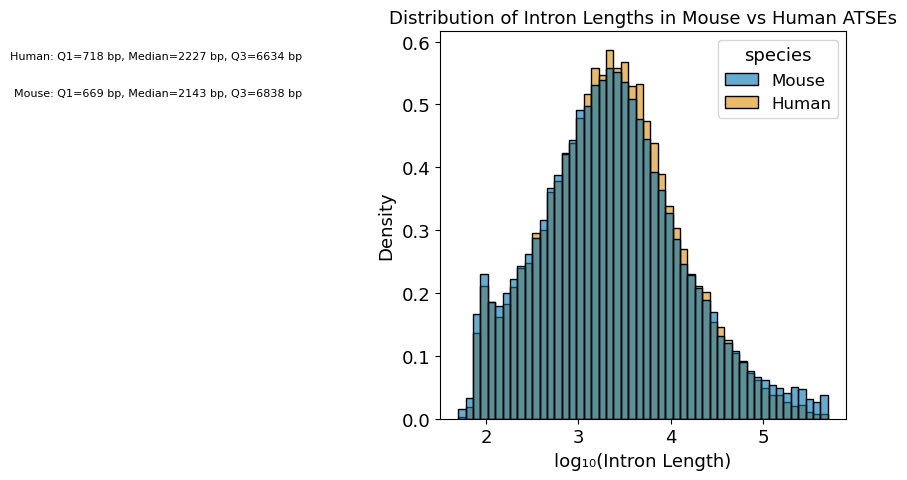

In [12]:
# Ensure raw intron length
mouse_atse["intron_length"] = mouse_atse["end"] - mouse_atse["start"]
human_atse["intron_length"] = human_atse["end"] - human_atse["start"]
mouse_atse["species"] = "Mouse"
human_atse["species"] = "Human"

# Combine
combined_df = pd.concat([mouse_atse, human_atse], ignore_index=True)
combined_df["log_intron_length"] = np.log10(combined_df["intron_length"])

# Compute raw percentiles
percentiles = (
    combined_df
    .groupby("species")["intron_length"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .rename(columns={0.25: "Q1", 0.5: "Median", 0.75: "Q3"})
)

# Plot log-scale histogram
plt.figure(figsize=(10, 5))
sns.histplot(
    data=combined_df,
    x="log_intron_length",
    hue="species",
    bins=50,
    stat="density",
    common_norm=False,
    alpha=0.6
)

# Horizontal annotation of raw values
text_y = plt.ylim()[1] * 0.95  # top of the plot
for i, (species, row) in enumerate(percentiles.iterrows()):
    text = f"{species}: Q1={int(row['Q1'])} bp, Median={int(row['Median'])} bp, Q3={int(row['Q3'])} bp"
    plt.text(
        0.01,  # near left edge
        text_y - i * 0.1 * text_y,  # space each line
        text,
        ha="right",
        va="top",
        fontsize=8,
        color="black"
    )

plt.xlabel("log₁₀(Intron Length)")
plt.ylabel("Density")
plt.title("Distribution of Intron Lengths in Mouse vs Human ATSEs")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'intron_lengths.pdf'), format='pdf', bbox_inches='tight')

plt.show()

In [13]:
from collections import defaultdict
from tqdm import tqdm

def load_all_bed_files():
    """Load all BED files for bidirectional analysis."""
    
    print("Loading all BED files...")
    
    # Original files
    mouse_bed = pd.read_csv(
        os.path.join(paths['results'], "mouse_junctions_mm10.bed"), 
        sep="\t", header=None,
        names=['chrom', 'start', 'end', 'name', 'score', 'strand']
    )
    
    human_bed = pd.read_csv(
        os.path.join(paths['results'], "human_junctions_hg38.bed"), 
        sep="\t", header=None,
        names=['chrom', 'start', 'end', 'name', 'score', 'strand']
    )
    
    # Lifted files
    mouse_lifted_to_human = pd.read_csv(
        os.path.join("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/plots_2025-08-06/results", "mouse_to_human_hglft_genome_1390cf_401bf0.bed"), 
        sep="\t", header=None,
        names=['chrom', 'start', 'end', 'name', 'score', 'strand']
    )
    
    human_lifted_to_mouse = pd.read_csv(
        os.path.join("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/plots_2025-08-06/results", "human_to_mouse_hglft_genome_13fcf6_402660.bed"), 
        sep="\t", header=None,
        names=['chrom', 'start', 'end', 'name', 'score', 'strand']
    )
    
    print(f"Original mouse junctions: {len(mouse_bed):,}")
    print(f"Original human junctions: {len(human_bed):,}")
    print(f"Mouse lifted to human: {len(mouse_lifted_to_human):,}")
    print(f"Human lifted to mouse: {len(human_lifted_to_mouse):,}")
    
    return mouse_bed, human_bed, mouse_lifted_to_human, human_lifted_to_mouse

def extract_junction_info_with_ensembl(name):
    """
    Extract junction info from BED name field, prioritizing Ensembl IDs.
    Format: chr_start_end_strand_geneName_eventID_ensemblID (or variations)
    """
    parts = name.split('_')
    
    if len(parts) >= 4:
        junction_id = '_'.join(parts[:4])  # chr_start_end_strand
        
        # Look for Ensembl gene ID (starts with ENSMUSG or ENSG)
        ensembl_id = None
        gene_name = 'Unknown'
        event_id = 'Unknown'
        
        for part in parts[4:]:
            if part.startswith('ENSMUSG') or part.startswith('ENSG'):
                ensembl_id = part
            elif part.startswith('ATSE_') or part.startswith('ENSG') or part.startswith('ENSMUSG'):
                event_id = part
            elif part not in ['Unknown', ''] and not part.startswith('ENS'):
                gene_name = part
        
        # If we found an Ensembl ID, use it as the primary identifier
        primary_gene_id = ensembl_id if ensembl_id else gene_name
        
        return junction_id, gene_name, event_id, ensembl_id, primary_gene_id
    else:
        return name, 'Unknown', 'Unknown', None, 'Unknown'

def find_matches_within_window(lifted_bed, target_bed, window_size=100, direction_name=""):
    """
    Find matches within a specified window size using Ensembl IDs when available.
    
    Args:
        lifted_bed: Lifted junction coordinates
        target_bed: Target junction coordinates to match against
        window_size: Maximum distance to consider a match (bp)
        direction_name: Name for progress tracking
        
    Returns:
        DataFrame with match results
    """
    
    print(f"Finding matches within {window_size:,}bp window for {direction_name}...")
    
    # Parse junction info for both datasets
    lifted_bed = lifted_bed.copy()
    target_bed = target_bed.copy()
    
    print("Parsing lifted junction info...")
    lifted_info = lifted_bed['name'].apply(extract_junction_info_with_ensembl)
    lifted_bed['junction_id'] = [x[0] for x in lifted_info]
    lifted_bed['gene_name'] = [x[1] for x in lifted_info] 
    lifted_bed['event_id'] = [x[2] for x in lifted_info]
    lifted_bed['ensembl_id'] = [x[3] for x in lifted_info]
    lifted_bed['primary_gene_id'] = [x[4] for x in lifted_info]
    
    print("Parsing target junction info...")
    target_info = target_bed['name'].apply(extract_junction_info_with_ensembl)
    target_bed['junction_id'] = [x[0] for x in target_info]
    target_bed['gene_name'] = [x[1] for x in target_info]
    target_bed['event_id'] = [x[2] for x in target_info]
    target_bed['ensembl_id'] = [x[3] for x in target_info]
    target_bed['primary_gene_id'] = [x[4] for x in target_info]
    
    # Check chromosome overlap
    lifted_chroms = set(lifted_bed['chrom'])
    target_chroms = set(target_bed['chrom'])
    common_chroms = lifted_chroms.intersection(target_chroms)
    missing_chroms = lifted_chroms - target_chroms
    
    print(f"Chromosome analysis:")
    print(f"  Lifted chromosomes: {len(lifted_chroms)} ({sorted(lifted_chroms)})")
    print(f"  Target chromosomes: {len(target_chroms)} ({sorted(target_chroms)})")
    print(f"  Common chromosomes: {len(common_chroms)} ({sorted(common_chroms)})")
    if missing_chroms:
        print(f"  Missing in target: {sorted(missing_chroms)}")
    
    # Group target junctions by chromosome for efficient lookup
    target_by_chrom = defaultdict(list)
    for idx, row in target_bed.iterrows():
        target_by_chrom[row['chrom']].append({
            'start': row['start'],
            'end': row['end'],
            'strand': row['strand'],
            'junction_id': row['junction_id'],
            'gene_name': row['gene_name'],
            'event_id': row['event_id'],
            'ensembl_id': row['ensembl_id'],
            'primary_gene_id': row['primary_gene_id'],
            'name': row['name']
        })
    
    results = []
    
    for idx, lifted_row in tqdm(lifted_bed.iterrows(), total=len(lifted_bed), 
                               desc=f"{direction_name} matching ({window_size:,}bp window)"):
        
        lifted_chrom = lifted_row['chrom']
        lifted_start = lifted_row['start']
        lifted_end = lifted_row['end']
        lifted_strand = lifted_row['strand']
        
        # Basic info
        result = {
            'lifted_junction_id': lifted_row['junction_id'],
            'lifted_gene_name': lifted_row['gene_name'],
            'lifted_ensembl_id': lifted_row['ensembl_id'],
            'lifted_primary_gene_id': lifted_row['primary_gene_id'],
            'lifted_event_id': lifted_row['event_id'],
            'lifted_coords': f"{lifted_chrom}:{lifted_start}-{lifted_end}",
            'lifted_strand': lifted_strand
        }
        
        # Check if chromosome exists in target
        if lifted_chrom not in target_by_chrom:
            result.update({
                'match_found': False,
                'match_type': 'chromosome_not_found',
                'target_junction_id': None,
                'target_gene_name': None,
                'target_ensembl_id': None,
                'target_primary_gene_id': None,
                'target_event_id': None,
                'start_distance': None,
                'end_distance': None,
                'total_distance': None,
                'explanation': f"Chromosome {lifted_chrom} not found in target dataset"
            })
            results.append(result)
            continue
        
        # Find best match within window
        best_match = None
        min_distance = float('inf')
        
        for target_junction in target_by_chrom[lifted_chrom]:
            
            # Check strand if specified
            if (lifted_strand != '.' and target_junction['strand'] != '.' and 
                lifted_strand != target_junction['strand']):
                continue
            
            # Calculate distances
            start_dist = abs(lifted_start - target_junction['start'])
            end_dist = abs(lifted_end - target_junction['end'])
            total_dist = start_dist + end_dist
            
            # Check if within window
            if start_dist <= window_size and end_dist <= window_size:
                if total_dist < min_distance:
                    min_distance = total_dist
                    best_match = {
                        'junction_id': target_junction['junction_id'],
                        'gene_name': target_junction['gene_name'],
                        'ensembl_id': target_junction['ensembl_id'],
                        'primary_gene_id': target_junction['primary_gene_id'],
                        'event_id': target_junction['event_id'],
                        'start_distance': start_dist,
                        'end_distance': end_dist,
                        'total_distance': total_dist
                    }
        
        if best_match:
            # Classify match quality
            if best_match['total_distance'] == 0:
                match_type = 'perfect_match'
            elif best_match['total_distance'] <= 2:
                match_type = 'excellent_match'
            elif best_match['total_distance'] <= 10:
                match_type = 'good_match'
            elif best_match['total_distance'] <= 50:
                match_type = 'acceptable_match'
            else:
                match_type = 'distant_match'
            
            result.update({
                'match_found': True,
                'match_type': match_type,
                'target_junction_id': best_match['junction_id'],
                'target_gene_name': best_match['gene_name'],
                'target_ensembl_id': best_match['ensembl_id'],
                'target_primary_gene_id': best_match['primary_gene_id'],
                'target_event_id': best_match['event_id'],
                'start_distance': best_match['start_distance'],
                'end_distance': best_match['end_distance'],
                'total_distance': best_match['total_distance'],
                'explanation': f"Match found with {best_match['total_distance']}bp total distance"
            })
        else:
            result.update({
                'match_found': False,
                'match_type': 'no_match_in_window',
                'target_junction_id': None,
                'target_gene_name': None,
                'target_ensembl_id': None,
                'target_primary_gene_id': None,
                'target_event_id': None,
                'start_distance': None,
                'end_distance': None,
                'total_distance': None,
                'explanation': f"No match found within {window_size}bp window on {lifted_chrom}"
            })
        
        results.append(result)
    
    return pd.DataFrame(results)

# Run with variable window size
window_size=10000
mouse_results = f"mouse_results_{window_size}"
human_results = f"human_results_{window_size}"
mouse_summary = f"mouse_summary_{window_size}"
human_summary = f"human_summary_{window_size}"
print(f"=== Junction Conservation Analysis ({window_size:,}bp window) ===")

# Load all BED files
mouse_bed, human_bed, mouse_lifted_to_human, human_lifted_to_mouse = load_all_bed_files()

# Analyze mouse to human conservation
mouse_to_human_results = find_matches_within_window(
        mouse_lifted_to_human, human_bed, window_size=window_size, direction_name="Mouse→Human"
    )
    
# Analyze human to mouse conservation
human_to_mouse_results = find_matches_within_window(
        human_lifted_to_mouse, mouse_bed, window_size=window_size, direction_name="Human→Mouse"
    )

# Then assign the results
print(f"\nConservation analysis complete with {window_size:,}bp window!")

=== Junction Conservation Analysis (10,000bp window) ===
Loading all BED files...
Original mouse junctions: 65,885
Original human junctions: 79,815
Mouse lifted to human: 61,882
Human lifted to mouse: 71,689
Finding matches within 10,000bp window for Mouse→Human...
Parsing lifted junction info...
Parsing target junction info...
Chromosome analysis:
  Lifted chromosomes: 24 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY'])
  Target chromosomes: 24 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY'])
  Common chromosomes: 24 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5',

Mouse→Human matching (10,000bp window): 100%|██████████| 61882/61882 [03:03<00:00, 336.74it/s]


Finding matches within 10,000bp window for Human→Mouse...
Parsing lifted junction info...
Parsing target junction info...
Chromosome analysis:
  Lifted chromosomes: 21 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY'])
  Target chromosomes: 21 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY'])
  Common chromosomes: 21 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY'])


Human→Mouse matching (10,000bp window): 100%|██████████| 71689/71689 [03:25<00:00, 348.31it/s]



Conservation analysis complete with 10,000bp window!


In [14]:
# Fixed extract_splice_sequences function for pyfaidx.Fasta
def extract_splice_sequences(chrom, start, end, strand, genome_fasta, exon_length=50):
    """
    Extract sequences around splice sites with proper strand orientation.
    Returns donor and acceptor sequences in transcript orientation.
    Works with pyfaidx.Fasta objects.
    """
    
    try:
        if strand == '+':
            # For + strand: donor at start (GT), acceptor at end (AG)
            donor_seq = genome_fasta[chrom][max(0, start - exon_length):start + 2].seq
            acceptor_seq = genome_fasta[chrom][end - 2:end + exon_length].seq
            donor_motif = genome_fasta[chrom][start:start + 2].seq
            acceptor_motif = genome_fasta[chrom][end - 2:end].seq
            
        else:  # strand == '-'
            # For - strand: flip coordinates and reverse complement
            donor_seq = str(Seq(genome_fasta[chrom][end - 2:end + exon_length].seq).reverse_complement())
            acceptor_seq = str(Seq(genome_fasta[chrom][max(0, start - exon_length):start + 2].seq).reverse_complement())
            donor_motif = str(Seq(genome_fasta[chrom][end - 2:end].seq).reverse_complement())
            acceptor_motif = str(Seq(genome_fasta[chrom][start:start + 2].seq).reverse_complement())
        
        return {
            'donor_seq': str(donor_seq),
            'acceptor_seq': str(acceptor_seq),
            'donor_motif': donor_motif,
            'acceptor_motif': acceptor_motif,
            'success': True
        }
        
    except Exception as e:
        return {
            'donor_seq': None,
            'acceptor_seq': None,
            'donor_motif': None,
            'acceptor_motif': None,
            'success': False,
            'error': str(e)
        }

def calculate_sequence_metrics(seq1, seq2):
    """Calculate both identity and similarity between two sequences."""
    
    if not seq1 or not seq2:
        return {'identity': 0.0, 'similarity': 0.0}
    
    try:
        # Simple global alignment
        alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
        
        if not alignments:
            return {'identity': 0.0, 'similarity': 0.0}
        
        aligned_seq1, aligned_seq2, score, start, end = alignments[0]
        
        # Calculate identity (exact matches only)
        matches = sum(c1 == c2 for c1, c2 in zip(aligned_seq1, aligned_seq2) 
                     if c1 != '-' and c2 != '-')
        
        # Calculate similarity (transitions get partial credit)
        transitions = {'A': 'G', 'G': 'A', 'C': 'T', 'T': 'C'}
        similarity_score = 0
        valid_positions = 0
        
        for c1, c2 in zip(aligned_seq1, aligned_seq2):
            if c1 != '-' and c2 != '-':
                valid_positions += 1
                if c1 == c2:
                    similarity_score += 1.0  # Perfect match
                elif transitions.get(c1) == c2:
                    similarity_score += 0.5  # Transition
                # Transversions get 0 points
        
        total_positions = max(len(seq1), len(seq2))
        identity = matches / total_positions if total_positions > 0 else 0.0
        similarity = similarity_score / total_positions if total_positions > 0 else 0.0
        
        return {'identity': identity, 'similarity': similarity}
        
    except:
        return {'identity': 0.0, 'similarity': 0.0}

def check_splice_motifs(motif1, motif2):
    """Check if splice motifs are canonical and conserved."""
    
    canonical_donors = {'GT', 'GC'}
    canonical_acceptor = {'AG'}
    
    # Check if both are canonical
    is_canonical = (motif1 in canonical_donors or motif1 in canonical_acceptor) and \
                   (motif2 in canonical_donors or motif2 in canonical_acceptor)
    
    # Check if conserved
    is_conserved = motif1 == motif2
    
    return is_canonical and is_conserved

# Fixed validation function
def validate_splice_junctions(conservation_results, source_genome, target_genome):
    """
    Simple validation focusing on:
    1. Exonic sequence conservation around splice sites
    2. Splice motif conservation (GT-AG, GC-AG)
    """
    
    print(f"Validating {len(conservation_results)} splice junctions...")
    
    # Filter for coordinate matches
    matched = conservation_results[conservation_results['match_found'] == True].copy()
    
    if len(matched) == 0:
        print("No matched junctions to validate")
        return pd.DataFrame()
    
    print(f"Analyzing {len(matched)} coordinate-matched junctions...")
    
    results = []
    
    for idx, row in tqdm(matched.iterrows(), total=len(matched), desc="Sequence validation"):
        
        try:
            # Parse coordinates
            source_parts = row['lifted_junction_id'].split('_')
            source_chrom, source_start, source_end, source_strand = \
                source_parts[0], int(source_parts[1]), int(source_parts[2]), source_parts[3]
            
            target_parts = row['target_junction_id'].split('_')
            target_chrom, target_start, target_end, target_strand = \
                target_parts[0], int(target_parts[1]), int(target_parts[2]), target_parts[3]
            
            # Check if chromosomes exist
            if source_chrom not in source_genome.keys() or target_chrom not in target_genome.keys():
                continue
            
            # Extract sequences
            source_seqs = extract_splice_sequences(
                source_chrom, source_start, source_end, source_strand, source_genome
            )
            target_seqs = extract_splice_sequences(
                target_chrom, target_start, target_end, target_strand, target_genome
            )
            
            if not (source_seqs['success'] and target_seqs['success']):
                continue
            
            # Calculate sequence conservation (both identity and similarity)
            donor_metrics = calculate_sequence_metrics(
                source_seqs['donor_seq'], target_seqs['donor_seq']
            )
            acceptor_metrics = calculate_sequence_metrics(
                source_seqs['acceptor_seq'], target_seqs['acceptor_seq']
            )
            
            # Average metrics
            average_identity = (donor_metrics['identity'] + acceptor_metrics['identity']) / 2
            average_similarity = (donor_metrics['similarity'] + acceptor_metrics['similarity']) / 2
            
            # Check splice motif conservation
            donor_motifs_ok = check_splice_motifs(
                source_seqs['donor_motif'], target_seqs['donor_motif']
            )
            acceptor_motifs_ok = check_splice_motifs(
                source_seqs['acceptor_motif'], target_seqs['acceptor_motif']
            )
            both_motifs_ok = donor_motifs_ok and acceptor_motifs_ok
            
            # Simple classification
            if average_similarity >= 0.7 and both_motifs_ok:
                validation = 'conserved'
            elif average_similarity >= 0.7:
                validation = 'sequence_only'
            elif both_motifs_ok:
                validation = 'motifs_only'
            else:
                validation = 'diverged'
            
            results.append({
                'junction_index': idx,
                'source_junction': row['lifted_junction_id'],
                'target_junction': row['target_junction_id'],
                'source_gene': row['lifted_primary_gene_id'],
                'target_gene': row['target_primary_gene_id'],
                'coordinate_distance': row['total_distance'],
                
                # Sequence conservation
                'donor_identity': donor_metrics['identity'],
                'acceptor_identity': acceptor_metrics['identity'],
                'average_identity': average_identity,
                'donor_similarity': donor_metrics['similarity'],
                'acceptor_similarity': acceptor_metrics['similarity'],
                'average_similarity': average_similarity,
                
                # Splice motifs
                'source_donor_motif': source_seqs['donor_motif'],
                'target_donor_motif': target_seqs['donor_motif'],
                'source_acceptor_motif': source_seqs['acceptor_motif'],
                'target_acceptor_motif': target_seqs['acceptor_motif'],
                'donor_motifs_conserved': donor_motifs_ok,
                'acceptor_motifs_conserved': acceptor_motifs_ok,
                'both_motifs_conserved': both_motifs_ok,
                
                # Overall assessment
                'validation_result': validation,
                'passes_70_percent': average_similarity >= 0.7
            })
            
        except Exception as e:
            # Silently continue for now
            continue
    
    results_df = pd.DataFrame(results)    
    return results_df

def run_simple_validation(conservation_results, source_genome, target_genome, 
                         direction_name, output_dir):
    """
    Run the simplified validation pipeline.
    """
    
    print(f"\n=== Simple Splice Junction Validation: {direction_name} ===")
    
    # Run validation
    validation_results = validate_splice_junctions(
        conservation_results, source_genome, target_genome
    )
    
    if len(validation_results) > 0:
        results_path = os.path.join(output_dir, 
                                  f"validation_{direction_name.lower().replace('→', '_to_')}.csv")
        validation_results.to_csv(results_path, index=False)
        print(f"Results saved: {results_path}")
        print(f"Successfully validated {len(validation_results)} junctions")
        
        # Quick distance analysis
        analyze_distance_conservation(validation_results)
    else:
        print("No validation results - all junctions failed validation")
    
    return validation_results

def analyze_distance_conservation(results_df):
    """Quick analysis of how coordinate distance relates to sequence conservation."""
    
    print(f"\n=== Distance vs Conservation Analysis ===")
    
    # Define distance bins
    bins = [0, 10, 100, 1000, float('inf')]
    labels = ['≤10bp', '11-100bp', '101-1000bp', '>1000bp']
    
    results_df['distance_bin'] = pd.cut(results_df['coordinate_distance'], 
                                       bins=bins, labels=labels, right=False)
    
    print(results_df)

In [15]:
# Now run the corrected validation
print("Running corrected validation...")
    
# Run full validation
mouse_validation = run_simple_validation(
    mouse_to_human_results, mouse_genome, human_genome, 
    "Mouse→Human", output_dir
)

human_validation = run_simple_validation(
    human_to_mouse_results, human_genome, mouse_genome,
    "Human→Mouse", output_dir
)

Running corrected validation...

=== Simple Splice Junction Validation: Mouse→Human ===
Validating 61882 splice junctions...
Analyzing 44736 coordinate-matched junctions...


Sequence validation: 100%|██████████| 44736/44736 [02:16<00:00, 328.41it/s]


Results saved: plots_2025-08-07/validation_mouse_to_human.csv
Successfully validated 44736 junctions

=== Distance vs Conservation Analysis ===
       junction_index         source_junction           target_junction  \
0                   2  chr1_5083278_5084416_+  chr8_53841725_53843033_-   
1                   3  chr1_5083625_5084416_+  chr8_53841725_53842870_-   
2                   6  chr1_5098133_5117389_+  chr8_53801896_53814661_-   
3                   7  chr1_5098133_5101069_+  chr8_53811217_53814661_-   
4                   8  chr1_5101123_5117389_+  chr8_53801896_53811163_-   
...               ...                     ...                       ...   
44731           61877  chrY_1263700_1263795_-  chrY_12916634_12916975_+   
44732           61878  chrY_1282948_1284321_-  chrY_12905815_12907536_+   
44733           61879  chrY_1282968_1284321_-  chrY_12905815_12907536_+   
44734           61880  chrY_1284382_1286478_-  chrY_12904981_12907536_+   
44735           61881  chrY_128

Sequence validation: 100%|██████████| 52386/52386 [01:59<00:00, 436.79it/s]


Results saved: plots_2025-08-07/validation_human_to_mouse.csv
Successfully validated 52386 junctions

=== Distance vs Conservation Analysis ===
       junction_index           source_junction             target_junction  \
0                   0      chr1_944800_945056_-  chr4_156242677_156243518_+   
1                   1      chr1_944800_945041_-  chr4_156242677_156243518_+   
2                   2      chr1_948594_951126_-  chr5_134518031_134522585_-   
3                   3      chr1_948603_951126_-  chr5_134518031_134522585_-   
4                   4      chr1_953892_954003_-  chr4_156240713_156241312_+   
...               ...                       ...                         ...   
52381           71684  chrY_19732742_19735351_-        chrY_910586_910685_+   
52382           71685  chrY_19732742_19733336_-        chrY_916710_916845_+   
52383           71686  chrY_19735750_19741317_-        chrY_900613_910447_+   
52384           71687  chrY_19737461_19739527_-        chrY_898627

/scratch/ipykernel_487965/4095719045.py:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=mouse_validation, x="distance_bin", y="average_similarity", inner="box", scale="width")


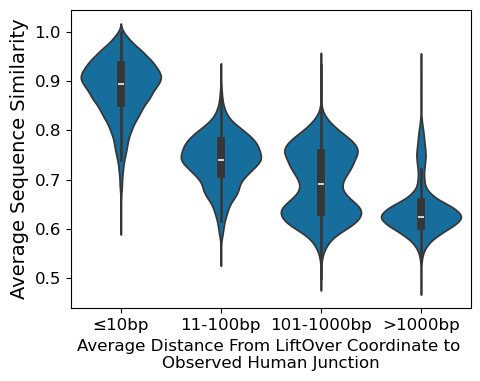

In [16]:
# Ensure distance_bin is a categorical type with ordered bins
bin_order = ["≤10bp", "11-100bp", "101-1000bp", ">1000bp"]
mouse_validation["distance_bin"] = pd.Categorical(mouse_validation["distance_bin"], categories=bin_order, ordered=True)

# Plot 1: Violin plot of average identity by distance_bin
plt.figure(figsize=(5, 4))
sns.violinplot(data=mouse_validation, x="distance_bin", y="average_similarity", inner="box", scale="width")
# INcrease font size 
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# Increase font size of the xlab and ylab 
plt.xlabel("Average Distance From LiftOver Coordinate to \nObserved Human Junction", fontsize=12)
plt.ylabel("Average Sequence Similarity", fontsize=14)
plt.tight_layout()
# save 
plt.savefig(os.path.join(paths['figures'], "sequence_identity_vs_coordinate_distance.pdf"), dpi=300)
plt.show()    

In [17]:
def find_atse_for_junction(junction_id, atse_df):
    """Find ATSE event containing this junction."""
    
    # Parse junction coordinates
    parts = junction_id.split('_')
    chrom, start, end, strand = parts[0], int(parts[1]), int(parts[2]), parts[3]
    
    # Find ATSE event containing this junction
    matching = atse_df[
        (atse_df['chrom'] == chrom) &
        (atse_df['start'] == start) &
        (atse_df['end'] == end) &
        (atse_df['strand'] == strand)
    ]
    
    return matching['event_id'].iloc[0] if len(matching) > 0 else None

In [18]:
def clean_pairs(validation_df, orthos_df, direction='mouse_to_human'):
    """
    Clean validation pairs by checking ortholog relationships and resolving duplicates.
    Maintains one-to-one junction relationships and uses only ortholog_one2one genes.
    
    Args:
        validation_df: DataFrame with validation results
        orthos_df: DataFrame with ortholog information from Ensembl
        direction: 'mouse_to_human' or 'human_to_mouse'
    
    Returns:
        Cleaned DataFrame with ortholog validation and duplicate resolution
    """
    
    print(f"Cleaning {len(validation_df)} validation pairs for {direction}...")
    
    # Work on a copy
    df = validation_df.copy()
    
    # Step 0: Filter orthologs to only one-to-one relationships
    print("Step 0: Filtering orthologs to one-to-one relationships...")
    orthos_one2one = orthos_df[orthos_df['Mouse homology type'] == 'ortholog_one2one'].copy()
    
    print(f"Ortholog filtering:")
    print(f"  Total orthologs: {len(orthos_df):,}")
    print(f"  One-to-one orthologs: {len(orthos_one2one):,}")
    print(f"  Filtered out: {len(orthos_df) - len(orthos_one2one):,}")
    
    # Step 1: Clean gene IDs by removing version numbers and dots
    print("Step 1: Cleaning gene IDs...")
    df['source_gene_clean'] = df['source_gene'].astype(str).str.replace(r'\.\d+$', '', regex=True).str.rstrip('.')
    df['target_gene_clean'] = df['target_gene'].astype(str).str.replace(r'\.\d+$', '', regex=True).str.rstrip('.')
    
    # Also clean ortholog DataFrame gene IDs
    orthos_clean = orthos_one2one.copy()
    orthos_clean['Gene stable ID'] = orthos_clean['Gene stable ID'].astype(str).str.replace(r'\.\d+$', '', regex=True).str.rstrip('.')
    orthos_clean['Mouse gene stable ID'] = orthos_clean['Mouse gene stable ID'].astype(str).str.replace(r'\.\d+$', '', regex=True).str.rstrip('.')
    
    # Step 2: Create ortholog lookup dictionaries based on direction
    print("Step 2: Creating one-to-one ortholog lookup...")
    
    if direction == 'mouse_to_human':
        # Source = mouse, Target = human
        # Create mouse -> human ortholog mapping
        ortholog_lookup = dict(zip(
            orthos_clean['Mouse gene stable ID'], 
            orthos_clean['Gene stable ID']
        ))
        source_col = 'source_gene_clean'  # mouse gene
        target_col = 'target_gene_clean'  # human gene
        
    else:  # human_to_mouse
        # Source = human, Target = mouse
        # Create human -> mouse ortholog mapping
        ortholog_lookup = dict(zip(
            orthos_clean['Gene stable ID'], 
            orthos_clean['Mouse gene stable ID']
        ))
        source_col = 'source_gene_clean'  # human gene
        target_col = 'target_gene_clean'  # mouse gene
    
    print(f"Found {len(ortholog_lookup)} one-to-one ortholog pairs in lookup")
    
    # Step 3: Check ortholog relationships
    print("Step 3: Validating ortholog relationships...")
    
    def check_ortholog_match(row):
        """Check if source and target genes are proper orthologs"""
        source_gene = row[source_col]
        target_gene = row[target_col]
        
        # Skip if either gene is missing/unknown
        if pd.isna(source_gene) or pd.isna(target_gene) or \
           source_gene in ['Unknown', 'nan', ''] or target_gene in ['Unknown', 'nan', '']:
            return 'missing_gene_info'
        
        # Check if source gene has an ortholog
        if source_gene not in ortholog_lookup:
            return 'source_not_in_orthologs'
        
        # Check if the target matches the expected ortholog
        expected_target = ortholog_lookup[source_gene]
        if target_gene == expected_target:
            return 'correct_ortholog'
        else:
            return 'incorrect_ortholog'
    
    df['ortholog_status'] = df.apply(check_ortholog_match, axis=1)
    
    # Print ortholog validation summary
    ortholog_counts = df['ortholog_status'].value_counts()
    print("\nOrtholog validation results:")
    for status, count in ortholog_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {status}: {count:,} ({percentage:.1f}%)")
    
    # Step 4: Filter for correct ortholog pairs only
    print("\nStep 4: Filtering for correct ortholog pairs...")
    correct_orthologs = df[df['ortholog_status'] == 'correct_ortholog'].copy()
    print(f"Kept {len(correct_orthologs):,} pairs with correct ortholog relationships")
    
    if len(correct_orthologs) == 0:
        print("Warning: No correct ortholog pairs found!")
        return correct_orthologs
    
    # Step 5: Handle multiple mappings - resolve BOTH source and target duplicates
    print("Step 5: Resolving duplicate mappings to maintain one-to-one relationships...")
    
    # First, handle multiple source junctions mapping to the same target junction
    print("  Step 5a: Resolving multiple sources → same target...")
    target_groups = correct_orthologs.groupby('target_junction')
    
    target_resolved = []
    target_duplicates = 0
    
    for target_junction, group in target_groups:
        if len(group) == 1:
            # Single mapping, keep as is
            target_resolved.append(group.iloc[0])
        else:
            # Multiple source junctions mapping to same target
            target_duplicates += len(group) - 1
            
            # Sort by: 1) highest average_similarity, 2) lowest coordinate_distance
            group_ranked = group.assign(
                similarity_rank=group['average_similarity'].rank(method='dense', ascending=False),
                distance_rank=group['coordinate_distance'].rank(method='dense', ascending=True)
            )
            group_ranked['combined_rank'] = group_ranked['similarity_rank'] + group_ranked['distance_rank']
            
            best_match = group_ranked.loc[group_ranked['combined_rank'].idxmin()]
            target_resolved.append(best_match)
    
    print(f"    Resolved {target_duplicates} duplicate target mappings")
    print(f"    Kept {len(target_resolved)} unique target junction mappings")
    
    # Convert back to DataFrame
    target_resolved_df = pd.DataFrame(target_resolved)
    
    # Second, handle multiple target junctions mapping to the same source junction
    print("  Step 5b: Resolving multiple targets ← same source...")
    source_groups = target_resolved_df.groupby('source_junction')
    
    final_pairs = []
    source_duplicates = 0
    
    for source_junction, group in source_groups:
        if len(group) == 1:
            # Single mapping, keep as is
            final_pairs.append(group.iloc[0])
        else:
            # Multiple target junctions mapping to same source
            source_duplicates += len(group) - 1
            
            # Sort by: 1) highest average_similarity, 2) lowest coordinate_distance
            group_ranked = group.assign(
                similarity_rank=group['average_similarity'].rank(method='dense', ascending=False),
                distance_rank=group['coordinate_distance'].rank(method='dense', ascending=True)
            )
            group_ranked['combined_rank'] = group_ranked['similarity_rank'] + group_ranked['distance_rank']
            
            best_match = group_ranked.loc[group_ranked['combined_rank'].idxmin()]
            final_pairs.append(best_match)
    
    print(f"    Resolved {source_duplicates} duplicate source mappings")
    print(f"    Final unique one-to-one mappings: {len(final_pairs)}")
    
    # Convert back to DataFrame
    final_df = pd.DataFrame(final_pairs)
    
    # Step 6: Verify one-to-one relationships
    print("Step 6: Verifying one-to-one junction relationships...")
    
    unique_source_junctions = final_df['source_junction'].nunique()
    unique_target_junctions = final_df['target_junction'].nunique()
    total_pairs = len(final_df)
    
    print(f"  Total pairs: {total_pairs:,}")
    print(f"  Unique source junctions: {unique_source_junctions:,}")
    print(f"  Unique target junctions: {unique_target_junctions:,}")
    
    if unique_source_junctions == unique_target_junctions == total_pairs:
        print("  ✅ Perfect one-to-one junction relationships maintained!")
    else:
        print("  ⚠️  Warning: Not perfect one-to-one relationships")
        
        # Check for any remaining duplicates
        duplicate_sources = final_df[final_df.duplicated('source_junction', keep=False)]
        duplicate_targets = final_df[final_df.duplicated('target_junction', keep=False)]
        
        if len(duplicate_sources) > 0:
            print(f"    Found {len(duplicate_sources)} pairs with duplicate source junctions")
        if len(duplicate_targets) > 0:
            print(f"    Found {len(duplicate_targets)} pairs with duplicate target junctions")
    
    # Step 7: Add summary statistics
    print("Step 7: Final summary...")
    
    # Calculate how many unique genes are represented
    unique_source_genes = final_df[source_col].nunique()
    unique_target_genes = final_df[target_col].nunique()
    
    print(f"Final results:")
    print(f"  Total validated pairs: {len(final_df):,}")
    print(f"  Unique source genes: {unique_source_genes:,}")
    print(f"  Unique target genes: {unique_target_genes:,}")
    print(f"  Average similarity: {final_df['average_similarity'].mean():.3f}")
    print(f"  Average coordinate distance: {final_df['coordinate_distance'].mean():.1f} bp")
    
    # Quality breakdown
    quality_counts = final_df['validation_result'].value_counts()
    print(f"\nQuality breakdown:")
    for quality, count in quality_counts.items():
        percentage = (count / len(final_df)) * 100
        print(f"  {quality}: {count:,} ({percentage:.1f}%)")
    
    return final_df


def analyze_filtering_impact(original_df, cleaned_df, direction):
    """Analyze the impact of the cleaning process."""
    
    print(f"\n=== Filtering Impact Analysis ({direction}) ===")
    
    original_count = len(original_df)
    cleaned_count = len(cleaned_df)
    retained_percentage = (cleaned_count / original_count) * 100 if original_count > 0 else 0
    
    print(f"Original pairs: {original_count:,}")
    print(f"Cleaned pairs: {cleaned_count:,}")
    print(f"Retention rate: {retained_percentage:.1f}%")
    
    if len(cleaned_df) > 0:
        # Compare quality metrics
        print(f"\nQuality comparison:")
        print(f"  Average similarity - Original: {original_df['average_similarity'].mean():.3f}, "
              f"Cleaned: {cleaned_df['average_similarity'].mean():.3f}")
        print(f"  Average distance - Original: {original_df['coordinate_distance'].mean():.1f} bp, "
              f"Cleaned: {cleaned_df['coordinate_distance'].mean():.1f} bp")
        
        # High quality pairs (>70% similarity)
        original_high_qual = (original_df['average_similarity'] > 0.7).sum()
        cleaned_high_qual = (cleaned_df['average_similarity'] > 0.7).sum()
        print(f"  High quality pairs (>70% similarity) - Original: {original_high_qual:,}, "
              f"Cleaned: {cleaned_high_qual:,}")


def clean_validation_results(mouse_validation_df, human_validation_df, orthos_df):
    """
    Clean both mouse-to-human and human-to-mouse validation results.
    
    Args:
        mouse_validation_df: Mouse to human validation results
        human_validation_df: Human to mouse validation results  
        orthos_df: Ortholog mapping DataFrame
    
    Returns:
        Tuple of (cleaned_mouse_results, cleaned_human_results)
    """
    
    print("=== Cleaning Validation Results ===")
    
    # Clean mouse to human results
    print("\n--- Cleaning Mouse → Human Results ---")
    cleaned_mouse = clean_pairs(mouse_validation_df, orthos_df, direction='mouse_to_human')
    analyze_filtering_impact(mouse_validation_df, cleaned_mouse, 'Mouse → Human')
    
    # Clean human to mouse results
    print("\n--- Cleaning Human → Mouse Results ---")
    cleaned_human = clean_pairs(human_validation_df, orthos_df, direction='human_to_mouse')
    analyze_filtering_impact(human_validation_df, cleaned_human, 'Human → Mouse')
    
    return cleaned_mouse, cleaned_human


def test_specific_case(cleaned_df, target_junction="chr3_114133189_114138170_+"):
    """Test function to verify specific cases like the target junction you mentioned."""
    
    print(f"\n=== Testing specific case: {target_junction} ===")
    
    # Find all pairs mapping to this target junction
    matches = cleaned_df[cleaned_df['target_junction'] == target_junction]
    
    print(f"Pairs mapping to {target_junction}: {len(matches)}")
    
    if len(matches) > 0:
        print("\nDetails:")
        for idx, row in matches.iterrows():
            print(f"  Source: {row['source_junction']}")
            print(f"  Distance: {row['coordinate_distance']:.1f} bp")
            print(f"  Similarity: {row['average_similarity']:.3f}")
            print(f"  Genes: {row['source_gene_clean']} → {row['target_gene_clean']}")
            print()
            
        if len(matches) == 1:
            best_row = matches.iloc[0]
            print(f"✅ Only one mapping kept (distance: {best_row['coordinate_distance']:.1f} bp)")
        else:
            print(f"⚠️  Still {len(matches)} mappings - function needs fixing!")
            
    return matches

# Clean the results
cleaned_mouse, cleaned_human = clean_validation_results(
    mouse_validation, human_validation, orthos
)

=== Cleaning Validation Results ===

--- Cleaning Mouse → Human Results ---
Cleaning 44736 validation pairs for mouse_to_human...
Step 0: Filtering orthologs to one-to-one relationships...
Ortholog filtering:
  Total orthologs: 179,006
  One-to-one orthologs: 155,136
  Filtered out: 23,870
Step 1: Cleaning gene IDs...
Step 2: Creating one-to-one ortholog lookup...
Found 17137 one-to-one ortholog pairs in lookup
Step 3: Validating ortholog relationships...

Ortholog validation results:
  correct_ortholog: 44,558 (99.6%)
  incorrect_ortholog: 178 (0.4%)

Step 4: Filtering for correct ortholog pairs...
Kept 44,558 pairs with correct ortholog relationships
Step 5: Resolving duplicate mappings to maintain one-to-one relationships...
  Step 5a: Resolving multiple sources → same target...
    Resolved 19440 duplicate target mappings
    Kept 25118 unique target junction mappings
  Step 5b: Resolving multiple targets ← same source...
    Resolved 0 duplicate source mappings
    Final unique on

In [19]:
atses_mouse_conserved = mouse_atse[mouse_atse["junction_id"].isin(cleaned_mouse["source_junction"])]
atses_human_conserved = human_atse[human_atse["junction_id"].isin(cleaned_mouse["target_junction"])]

print(f"Number of conserved junctions in mouse_atse: {atses_mouse_conserved.shape[0]}")
print(f"Number of conserved junctions in human_atse: {atses_human_conserved.shape[0]}")

Number of conserved junctions in mouse_atse: 25118
Number of conserved junctions in human_atse: 25118


In [20]:
# Create conserved datasets with validation mapping information AND annotation status
print("=== Creating Mapped Conserved Datasets with Annotation Status ===")

# Step 1: Create junction lookup tables with annotation status from original ATSE data
print("Step 1: Creating annotation lookup tables...")

# Create mouse junction annotation lookup
mouse_annotation_lookup = mouse_atse.groupby('junction_id')['annotation_status'].first().to_dict()
print(f"Mouse annotation lookup: {len(mouse_annotation_lookup):,} junctions")

# Create human junction annotation lookup  
human_annotation_lookup = human_atse.groupby('junction_id')['annotation_status'].first().to_dict()
print(f"Human annotation lookup: {len(human_annotation_lookup):,} junctions")

# Step 2: Create the junction mapping table with validation info
junction_mapping = cleaned_mouse[['source_junction', 'target_junction', 'source_gene_clean', 
                                 'target_gene_clean', 'average_similarity', 'average_identity',
                                 'coordinate_distance', 'validation_result', 'both_motifs_conserved',
                                 'source_donor_motif', 'target_donor_motif', 
                                 'source_acceptor_motif', 'target_acceptor_motif']].copy()

# Step 3: Add annotation status for both species
print("Step 3: Adding annotation status...")

# Add mouse annotation status
junction_mapping['mouse_annotation_status'] = junction_mapping['source_junction'].map(mouse_annotation_lookup)

# Add human annotation status
junction_mapping['human_annotation_status'] = junction_mapping['target_junction'].map(human_annotation_lookup)

# Rename columns for clarity
junction_mapping.columns = ['mouse_junction_id', 'human_junction_id', 'mouse_gene', 'human_gene', 
                           'sequence_similarity', 'sequence_identity', 'coordinate_distance', 
                           'conservation_status', 'motifs_conserved', 'mouse_donor_motif', 
                           'human_donor_motif', 'mouse_acceptor_motif', 'human_acceptor_motif',
                           'mouse_annotation_status', 'human_annotation_status']

print(f"Junction mapping table created: {len(junction_mapping):,} one-to-one pairs")

# Step 4: Check annotation status coverage
mouse_annotation_missing = junction_mapping['mouse_annotation_status'].isna().sum()
human_annotation_missing = junction_mapping['human_annotation_status'].isna().sum()

print(f"\nAnnotation status coverage:")
print(f"  Mouse junctions with annotation: {len(junction_mapping) - mouse_annotation_missing:,}/{len(junction_mapping):,}")
print(f"  Human junctions with annotation: {len(junction_mapping) - human_annotation_missing:,}/{len(junction_mapping):,}")

if mouse_annotation_missing > 0:
    print(f"  Missing mouse annotations: {mouse_annotation_missing:,}")
if human_annotation_missing > 0:
    print(f"  Missing human annotations: {human_annotation_missing:,}")

# Step 5: Get conserved junctions (your original approach)
atses_mouse_conserved = mouse_atse[mouse_atse["junction_id"].isin(cleaned_mouse["source_junction"])].copy()
atses_human_conserved = human_atse[human_atse["junction_id"].isin(cleaned_mouse["target_junction"])].copy()

print(f"\nMouse conserved junctions: {atses_mouse_conserved.shape[0]:,}")
print(f"Human conserved junctions: {atses_human_conserved.shape[0]:,}")

# Step 6: Add validation information to the junction datasets
print("\n=== Adding Validation Information ===")

# Merge mouse data with validation info (including annotation status)
atses_mouse_conserved_mapped = atses_mouse_conserved.merge(
    junction_mapping[['mouse_junction_id', 'human_junction_id', 'mouse_gene', 'human_gene',
                     'sequence_similarity', 'sequence_identity', 'coordinate_distance', 
                     'conservation_status', 'motifs_conserved', 'mouse_annotation_status', 
                     'human_annotation_status']],
    left_on='junction_id', 
    right_on='mouse_junction_id',
    how='left'
)

# Merge human data with validation info (including annotation status)
atses_human_conserved_mapped = atses_human_conserved.merge(
    junction_mapping[['human_junction_id', 'mouse_junction_id', 'mouse_gene', 'human_gene',
                     'sequence_similarity', 'sequence_identity', 'coordinate_distance', 
                     'conservation_status', 'motifs_conserved', 'mouse_annotation_status',
                     'human_annotation_status']],
    left_on='junction_id',
    right_on='human_junction_id', 
    how='left'
)

print(f"Mouse dataset with validation info: {atses_mouse_conserved_mapped.shape[0]:,} rows")
print(f"Human dataset with validation info: {atses_human_conserved_mapped.shape[0]:,} rows")

# Step 7: Add direct partner IDs to the datasets for easy access
atses_mouse_conserved_mapped['partner_human_junction'] = atses_mouse_conserved_mapped['human_junction_id']
atses_human_conserved_mapped['partner_mouse_junction'] = atses_human_conserved_mapped['mouse_junction_id']

# Step 8: Analyze annotation status patterns
print(f"\n=== Annotation Status Analysis ===")

# Mouse annotation distribution
print("Mouse annotation status distribution:")
mouse_annotation_counts = junction_mapping['mouse_annotation_status'].value_counts()
for status, count in mouse_annotation_counts.items():
    percentage = (count / len(junction_mapping)) * 100
    print(f"  {status}: {count:,} ({percentage:.1f}%)")

# Human annotation distribution
print("\nHuman annotation status distribution:")
human_annotation_counts = junction_mapping['human_annotation_status'].value_counts()
for status, count in human_annotation_counts.items():
    percentage = (count / len(junction_mapping)) * 100
    print(f"  {status}: {count:,} ({percentage:.1f}%)")

# Cross-species annotation comparison
print("\nCross-species annotation patterns:")
annotation_crosstab = pd.crosstab(junction_mapping['mouse_annotation_status'], 
                                 junction_mapping['human_annotation_status'], 
                                 margins=True, dropna=False)
print(annotation_crosstab)

# Step 9: Create summary statistics
print(f"\n=== Summary Statistics ===")
print(f"Conservation quality distribution:")
conservation_counts = junction_mapping['conservation_status'].value_counts()
for status, count in conservation_counts.items():
    percentage = (count / len(junction_mapping)) * 100
    print(f"  {status}: {count:,} ({percentage:.1f}%)")

print(f"\nSequence similarity statistics:")
print(f"  Mean similarity: {junction_mapping['sequence_similarity'].mean():.3f}")
print(f"  Median similarity: {junction_mapping['sequence_similarity'].median():.3f}")
print(f"  High similarity (>90%): {(junction_mapping['sequence_similarity'] > 0.9).sum():,}")

# Step 10: Updated lookup functions
def get_human_partner(mouse_junction_id):
    """Get the human partner junction for a given mouse junction"""
    match = junction_mapping[junction_mapping['mouse_junction_id'] == mouse_junction_id]
    if len(match) > 0:
        return match.iloc[0]['human_junction_id']
    return None

def get_mouse_partner(human_junction_id):
    """Get the mouse partner junction for a given human junction"""
    match = junction_mapping[junction_mapping['human_junction_id'] == human_junction_id]
    if len(match) > 0:
        return match.iloc[0]['mouse_junction_id']
    return None

def get_junction_pair_info(mouse_junction_id=None, human_junction_id=None):
    """Get complete information about a junction pair including annotation status"""
    if mouse_junction_id:
        match = junction_mapping[junction_mapping['mouse_junction_id'] == mouse_junction_id]
    elif human_junction_id:
        match = junction_mapping[junction_mapping['human_junction_id'] == human_junction_id]
    else:
        return None
    
    if len(match) > 0:
        return match.iloc[0].to_dict()
    return None

=== Creating Mapped Conserved Datasets with Annotation Status ===
Step 1: Creating annotation lookup tables...
Mouse annotation lookup: 65,885 junctions
Human annotation lookup: 79,815 junctions
Step 3: Adding annotation status...
Junction mapping table created: 25,118 one-to-one pairs

Annotation status coverage:
  Mouse junctions with annotation: 25,118/25,118
  Human junctions with annotation: 25,118/25,118

Mouse conserved junctions: 25,118
Human conserved junctions: 25,118

=== Adding Validation Information ===
Mouse dataset with validation info: 25,118 rows
Human dataset with validation info: 25,118 rows

=== Annotation Status Analysis ===
Mouse annotation status distribution:
  both: 20,220 (80.5%)
  five_prime: 2,038 (8.1%)
  three_prime: 1,680 (6.7%)
  unannotated: 1,180 (4.7%)

Human annotation status distribution:
  both: 20,863 (83.1%)
  five_prime: 2,037 (8.1%)
  three_prime: 2,003 (8.0%)
  unannotated: 215 (0.9%)

Cross-species annotation patterns:
human_annotation_status

In [21]:
def visualize_junction_pair(junction_id, junction_mapping, mouse_atse_df, human_atse_df,
                          db_mouse, db_human, output_dir):
    """
    Visualize a junction pair by providing either mouse or human junction ID.
    
    Args:
        junction_id: Either mouse or human junction ID
        junction_mapping: Junction mapping DataFrame
        mouse_atse_df: Mouse ATSE data
        human_atse_df: Human ATSE data  
        db_mouse: Mouse genome database
        db_human: Human genome database
        output_dir: Output directory
    """
    
    # Find the junction pair
    if junction_id in junction_mapping['mouse_junction_id'].values:
        pair = junction_mapping[junction_mapping['mouse_junction_id'] == junction_id].iloc[0]
        mouse_junction = pair['mouse_junction_id']
        human_junction = pair['human_junction_id']
    elif junction_id in junction_mapping['human_junction_id'].values:
        pair = junction_mapping[junction_mapping['human_junction_id'] == junction_id].iloc[0]
        mouse_junction = pair['mouse_junction_id'] 
        human_junction = pair['human_junction_id']
    else:
        print(f"Junction {junction_id} not found in mapping")
        return None
    
    print(f"Visualizing: {mouse_junction} ↔ {human_junction}")
    print(f"Similarity: {pair['sequence_similarity']:.3f}")
    
    # Find ATSE events
    mouse_event = mouse_atse_df[mouse_atse_df['junction_id'] == mouse_junction]['event_id'].iloc[0]
    human_event = human_atse_df[human_atse_df['junction_id'] == human_junction]['event_id'].iloc[0]
    
    # Create output directory
    out_dir = os.path.join(output_dir, f"{pair['mouse_gene']}_{pair['human_gene']}")
    os.makedirs(out_dir, exist_ok=True)
    
    # Visualize both
    visualize_atse_event(mouse_event, mouse_atse_df, db_mouse, "mouse", out_dir)
    visualize_atse_event(human_event, human_atse_df, db_human, "human", out_dir)
    
    print(f"Saved to: {out_dir}")
    return out_dir

In [22]:
# Define conditions
conditions = [
    (junction_mapping["coordinate_distance"] <= 100) & (junction_mapping["conservation_status"] == "conserved"),
    (junction_mapping["coordinate_distance"] > 100) & 
    (junction_mapping["coordinate_distance"] < 10000)]

# Corresponding outputs
choices = ["high_confidence", "medium_confidence"]

# Default case: all others are low confidence
junction_mapping["conservation_confidence"] = np.select(conditions, choices, default="low_confidence")

In [23]:
junction_mapping["conservation_confidence"].value_counts()

conservation_confidence
high_confidence      17234
medium_confidence     6687
low_confidence        1197
Name: count, dtype: int64

In [24]:
junction_mapping.sort_values(by="sequence_similarity")

,mouse_junction_id,human_junction_id,mouse_gene,human_gene,sequence_similarity,sequence_identity,coordinate_distance,conservation_status,motifs_conserved,mouse_donor_motif,human_donor_motif,mouse_acceptor_motif,human_acceptor_motif,mouse_annotation_status,human_annotation_status,conservation_confidence
26798,chr3_108202292_108207484_-,chr1_109487804_109488846_+,ENSMUSG00000048997,ENSG00000162650,0.490385,0.490385,4498.0,motifs_only,True,GT,GT,AG,AG,unannotated,both,medium_confidence
12575,chr14_56676618_56677017_+,chr13_19647456_19648421_+,ENSMUSG00000079184,ENSG00000196199,0.500000,0.500000,1428.0,motifs_only,True,GT,GT,AG,AG,five_prime,three_prime,medium_confidence
6526,chr11_71018374_71019143_-,chr17_5481389_5482808_-,ENSMUSG00000018442,ENSG00000072849,0.509615,0.509615,7084.0,motifs_only,True,GT,GT,AG,AG,five_prime,both,medium_confidence
18568,chr17_84563997_84565970_+,chr2_43700608_43700970_+,ENSMUSG00000040852,ENSG00000152527,0.509615,0.509615,4576.0,motifs_only,True,GT,GT,AG,AG,both,five_prime,medium_confidence
744,chr1_74459980_74461565_-,chr2_218482234_218485612_-,ENSMUSG00000033364,ENSG00000135913,0.509615,0.509615,6062.0,motifs_only,True,GT,GT,AG,AG,both,three_prime,medium_confidence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19630,chr18_77150098_77152614_+,chr18_46812612_46815311_-,ENSMUSG00000025423,ENSG00000078043,1.000000,1.000000,0.0,conserved,True,GT,GT,AG,AG,both,both,high_confidence
19628,chr18_77150098_77152611_+,chr18_46812615_46815311_-,ENSMUSG00000025423,ENSG00000078043,1.000000,1.000000,0.0,conserved,True,GT,GT,AG,AG,five_prime,both,high_confidence
6690,chr11_75053963_75139192_+,chr17_2085901_2172657_-,ENSMUSG00000038290,ENSG00000070366,1.000000,1.000000,0.0,conserved,True,GT,GT,AG,AG,both,both,high_confidence
10128,chr12_105809662_105812273_+,chr14_96532649_96535878_+,ENSMUSG00000021111,ENSG00000090060,1.000000,1.000000,0.0,conserved,True,GT,GT,AG,AG,both,both,high_confidence


Visualizing: chr5_129504152_129504262_+ ↔ chr12_131714240_131714354_+
Similarity: 1.000
Unique transcripts: ['ENSMUST00000053737.8', 'ENSMUST00000196147.1', 'ENSMUST00000196698.4', 'ENSMUST00000199925.4', 'ENSMUST00000200500.1']
Unique transcripts to remove: []
Plot saved to plots_2025-08-07/ENSMUSG00000029439_ENSG00000061936/005214_mouse_Sfswap_ENSMUSG00000029439.14_atse_2.pdf!


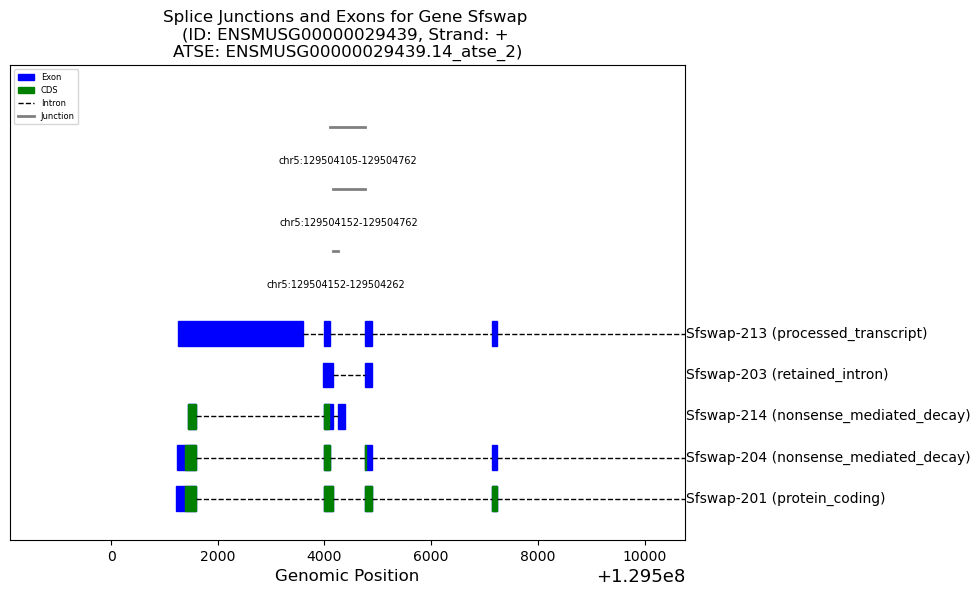

ATSE visualization saved: plots_2025-08-07/ENSMUSG00000029439_ENSG00000061936/005214_mouse_Sfswap_ENSMUSG00000029439.14_atse_2.pdf
Unique transcripts: ['ENST00000261674.9']
Unique transcripts to remove: ['s-4561987860927819973:e-2807200837151318813', 's-7144267084232043622:e-4909808714614318700']
Plot saved to plots_2025-08-07/ENSMUSG00000029439_ENSG00000061936/005215_human_nan_ENSG00000061936.10_atse_2.pdf!


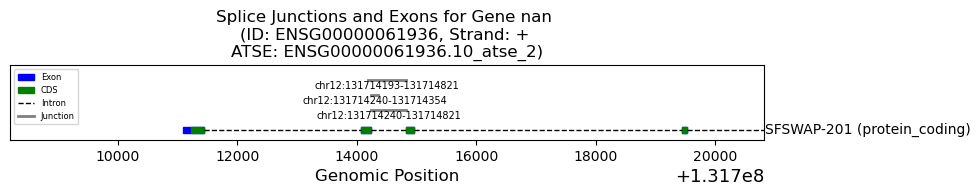

ATSE visualization saved: plots_2025-08-07/ENSMUSG00000029439_ENSG00000061936/005215_human_nan_ENSG00000061936.10_atse_2.pdf
Saved to: plots_2025-08-07/ENSMUSG00000029439_ENSG00000061936


'plots_2025-08-07/ENSMUSG00000029439_ENSG00000061936'

In [25]:
# Usage
visualize_junction_pair("chr5_129504152_129504262_+", junction_mapping, mouse_atse, human_atse, db_mouse, db_human, output_dir)

In [26]:
junction_mapping

,mouse_junction_id,human_junction_id,mouse_gene,human_gene,sequence_similarity,sequence_identity,coordinate_distance,conservation_status,motifs_conserved,mouse_donor_motif,human_donor_motif,mouse_acceptor_motif,human_acceptor_motif,mouse_annotation_status,human_annotation_status,conservation_confidence
4407,chr10_100080130_100080856_+,chr12_88515617_88516333_-,ENSMUSG00000019966,ENSG00000049130,0.942308,0.942308,0.0,conserved,True,GT,GT,AG,AG,both,both,high_confidence
4406,chr10_100080130_100087346_+,chr12_88507137_88516333_-,ENSMUSG00000019966,ENSG00000049130,0.846154,0.846154,0.0,conserved,True,GT,GT,AG,AG,both,both,high_confidence
4408,chr10_100080940_100087346_+,chr12_88507137_88515533_-,ENSMUSG00000019966,ENSG00000049130,0.903846,0.903846,0.0,conserved,True,GT,GT,AG,AG,both,both,high_confidence
4409,chr10_100478022_100487161_-,chr12_88142487_88148287_+,ENSMUSG00000036676,ENSG00000139324,0.769231,0.769231,0.0,conserved,True,GT,GT,AG,AG,both,both,high_confidence
4414,chr10_100512399_100513560_+,chr12_88115570_88117032_-,ENSMUSG00000019971,ENSG00000198707,0.836538,0.836538,0.0,conserved,True,GT,GT,AG,AG,five_prime,five_prime,high_confidence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44698,chrY_916710_916845_+,chrY_19732742_19733336_-,ENSMUSG00000056673,ENSG00000012817,0.644231,0.644231,2053.0,motifs_only,True,GT,GT,AG,AG,three_prime,three_prime,medium_confidence
44702,chrY_927439_927602_+,chrY_19716111_19716278_-,ENSMUSG00000056673,ENSG00000012817,0.894231,0.894231,0.0,conserved,True,GT,GT,AG,AG,both,five_prime,high_confidence
44703,chrY_927439_927709_+,chrY_19716004_19716278_-,ENSMUSG00000056673,ENSG00000012817,0.932692,0.932692,0.0,conserved,True,GT,GT,AG,AG,both,both,high_confidence
44705,chrY_938171_939818_+,chrY_19709578_19710375_-,ENSMUSG00000056673,ENSG00000012817,0.586538,0.586538,1490.0,motifs_only,True,GT,GT,AG,AG,both,both,medium_confidence


In [27]:
# Add species column
mouse_cons = mouse_atse[mouse_atse["junction_id"].isin(junction_mapping["mouse_junction_id"].values)]
human_cons = human_atse[human_atse["junction_id"].isin(junction_mapping["human_junction_id"].values)]

# Combine datasets
combined_df = pd.concat([mouse_cons, human_cons], ignore_index=True)

gene_df = orthos[["Gene name", "Gene stable ID"]].drop_duplicates().rename(
    columns={
        "Gene name": "human_gene_name",
        "Gene stable ID": "human_gene"
    }
)

junction_mapping = junction_mapping.merge(gene_df)

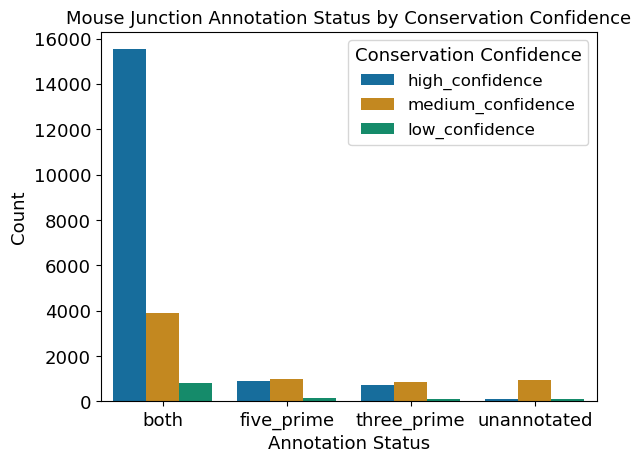

In [28]:
# Ordered bar plot by conservation confidence
sns.countplot(
    data=junction_mapping,
    x="mouse_annotation_status",
    hue="conservation_confidence",
    hue_order=["high_confidence", "medium_confidence", "low_confidence"]
)

plt.title("Mouse Junction Annotation Status by Conservation Confidence")
plt.ylabel("Count")
plt.xlabel("Annotation Status")
plt.legend(title="Conservation Confidence")

In [29]:
# Save the enhanced mapping table
mapping_file = os.path.join(output_dir, 'junction_mapping_mouse_human_with_annotations.csv')
junction_mapping.to_csv(mapping_file, index=False)
print(f"\n💾 Enhanced junction mapping saved to: {mapping_file}")


💾 Enhanced junction mapping saved to: plots_2025-08-07/junction_mapping_mouse_human_with_annotations.csv


### Differential Splicing analysis

In [30]:
# Load differential splicing results for factors 
DATA_DIR_MOUSE = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/data"
DATA_DIR_HUMAN = "/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/data/"

mouse_ds = pd.read_csv(f"{DATA_DIR_MOUSE}/differential_splicing_results.csv")
human_ds = pd.read_csv(f"{DATA_DIR_HUMAN}/differential_splicing_results.csv")

PI_VALUES_PATH_MOUSE = f"{DATA_DIR_MOUSE}/PI_values.npy"
PI_VALUES_PATH_HUMAN = f"{DATA_DIR_HUMAN}/PI_values.npy"

mouse_pi = np.load(PI_VALUES_PATH_MOUSE)
human_pi = np.load(PI_VALUES_PATH_HUMAN)

In [31]:
# Get new factor order (indices sorted by decreasing PI)
new_order_mouse = np.argsort(-mouse_pi)  # minus for descending sort
new_order_human = np.argsort(-human_pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order_mouse):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {mouse_pi[idx]:.4f}")

old_to_new_factor_idx_mouse = {old: new for new, old in enumerate(new_order_mouse)}
print(old_to_new_factor_idx_mouse)

# Rename the factor labels now that we changed it based on pi 
mouse_ds = mouse_ds.rename(columns={"factor_idx": "old_factor_idx"})
mouse_ds["factor_idx"] = mouse_ds["old_factor_idx"].map(old_to_new_factor_idx_mouse)


for rank, idx in enumerate(new_order_human):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {human_pi[idx]:.4f}")

old_to_new_factor_idx_human = {old: new for new, old in enumerate(new_order_human)}
print(old_to_new_factor_idx_human)

# now do the same for human 
human_ds = human_ds.rename(columns={"factor_idx": "old_factor_idx"})
human_ds["factor_idx"] = human_ds["old_factor_idx"].map(old_to_new_factor_idx_human)

Sorted pi values with original factor indices:
Rank 1: Factor 2 → PI = 0.1451
Rank 2: Factor 0 → PI = 0.1417
Rank 3: Factor 1 → PI = 0.1131
Rank 4: Factor 6 → PI = 0.0708
Rank 5: Factor 12 → PI = 0.0475
Rank 6: Factor 4 → PI = 0.0439
Rank 7: Factor 13 → PI = 0.0421
Rank 8: Factor 9 → PI = 0.0389
Rank 9: Factor 14 → PI = 0.0385
Rank 10: Factor 3 → PI = 0.0378
Rank 11: Factor 11 → PI = 0.0373
Rank 12: Factor 15 → PI = 0.0368
Rank 13: Factor 7 → PI = 0.0362
Rank 14: Factor 5 → PI = 0.0351
Rank 15: Factor 8 → PI = 0.0350
Rank 16: Factor 10 → PI = 0.0313
Rank 17: Factor 16 → PI = 0.0212
Rank 18: Factor 17 → PI = 0.0178
Rank 19: Factor 18 → PI = 0.0164
Rank 20: Factor 19 → PI = 0.0135
{2: 0, 0: 1, 1: 2, 6: 3, 12: 4, 4: 5, 13: 6, 9: 7, 14: 8, 3: 9, 11: 10, 15: 11, 7: 12, 5: 13, 8: 14, 10: 15, 16: 16, 17: 17, 18: 18, 19: 19}
Rank 1: Factor 10 → PI = 0.0921
Rank 2: Factor 1 → PI = 0.0876
Rank 3: Factor 0 → PI = 0.0858
Rank 4: Factor 7 → PI = 0.0777
Rank 5: Factor 2 → PI = 0.0767
Rank 6: Factor 

In [32]:
def summarize_atses(atses_df, species_label):
    summary = {
        "Species": species_label,
        "Junctions": atses_df.shape[0],
        "Unique ATSEs": atses_df["event_id"].nunique(),
        "Unique Genes": atses_df["gene_id"].nunique(),
        "Junction Annotation Counts": atses_df["annotation_status"].value_counts().to_dict()
    }
    return summary

mouse_summary = summarize_atses(atses_mouse_conserved, "Mouse")
human_summary = summarize_atses(atses_human_conserved, "Human")

# Combine and display as DataFrame
summary_df = pd.DataFrame([mouse_summary, human_summary])
print(summary_df)

  Species  Junctions  Unique ATSEs  Unique Genes  \
0   Mouse      25118         15202          7915   
1   Human      25118         14537          7915   

                          Junction Annotation Counts  
0  {'both': 20220, 'five_prime': 2038, 'three_pri...  
1  {'both': 20863, 'five_prime': 2037, 'three_pri...  


In [43]:
# mouse aging factor 2 (start with this one first) and human seems to be also 2 maybe 
# filter for DS in mouse_df for factor 2
mouse_ds_factor2 = mouse_ds[mouse_ds['factor_idx'] == 0]
human_ds_factor2 = human_ds[human_ds['factor_idx'] == 0]

In [44]:
mouse_juncs = mouse_ds_factor2["junction_id"].values 
human_juncs = human_ds_factor2["junction_id"].values 

# Get the specified rank junction
sorted_results = mouse_validation.sort_values(by="average_similarity", ascending=False)

conserved_df = sorted_results[
    sorted_results["source_junction"].isin(mouse_juncs) &
    sorted_results["target_junction"].isin(human_juncs)
]

conserved_df = conserved_df.sort_values(by="average_similarity", ascending=False)
print(f"Number of conserved junctions: {conserved_df.shape[0]}")


Number of conserved junctions: 545


In [45]:
# Step 1: Count how many times each source and target junction appears
source_counts = conserved_df["source_junction"].value_counts()
target_counts = conserved_df["target_junction"].value_counts()

# Step 2: Keep only junctions that appear exactly once in both columns
one_to_one_sources = source_counts[source_counts == 1].index
one_to_one_targets = target_counts[target_counts == 1].index

# Step 3: Subset conserved_df to 1:1 junction pairs
conserved_1to1_df = conserved_df[
    conserved_df["source_junction"].isin(one_to_one_sources) &
    conserved_df["target_junction"].isin(one_to_one_targets)
]

# Sanity check
print(f"1:1 conserved junction pairs: {conserved_1to1_df.shape[0]}")

1:1 conserved junction pairs: 518


In [46]:
# subset human_ds_factor2 and mouse_ds_factor2 for the conserved junctions 
human_ds_factor2_conserved = human_ds_factor2[human_ds_factor2["junction_id"].isin(conserved_1to1_df["target_junction"].values)]
mouse_ds_factor2_conserved = mouse_ds_factor2[mouse_ds_factor2["junction_id"].isin(conserved_1to1_df["source_junction"].values)]

# print the number of conserved junctions in human_ds_factor2_conserved and mouse_ds_factor2_conserved
print(f"Number of conserved junctions in human_ds_factor2_conserved: {human_ds_factor2_conserved.shape[0]}")
print(f"Number of conserved junctions in mouse_ds_factor2_conserved: {mouse_ds_factor2_conserved.shape[0]}")

Number of conserved junctions in human_ds_factor2_conserved: 518
Number of conserved junctions in mouse_ds_factor2_conserved: 518


In [47]:
conserved_1to1_df

,junction_index,source_junction,target_junction,source_gene,target_gene,coordinate_distance,donor_identity,acceptor_identity,average_identity,donor_similarity,...,source_donor_motif,target_donor_motif,source_acceptor_motif,target_acceptor_motif,donor_motifs_conserved,acceptor_motifs_conserved,both_motifs_conserved,validation_result,passes_70_percent,distance_bin
25695,35506,chr3_65951554_65956852_-,chr3_157153156_157158865_-,ENSMUSG00000027829.15,ENSG00000163660.12,0.0,1.000000,1.000000,1.000000,1.000000,...,GT,GT,AG,AG,True,True,True,conserved,True,≤10bp
29916,41369,chr4_151062855_151071425_-,chr1_7755668_7766458_+,ENSMUSG00000014592.20,ENSG00000171735.21,0.0,1.000000,1.000000,1.000000,1.000000,...,GT,GT,AG,AG,True,True,True,conserved,True,≤10bp
20068,27744,chr19_5903772_5904239_-,chr11_65344069_65344579_+,ENSMUSG00000024826.14,ENSG00000133884.11,0.0,1.000000,1.000000,1.000000,1.000000,...,GT,GT,AG,AG,True,True,True,conserved,True,≤10bp
13875,19479,chr15_76074657_76075541_-,chr8_143820716_143821596_-,ENSMUSG00000002524.17,ENSG00000179950.15,0.0,0.980769,1.000000,0.990385,0.980769,...,GT,GT,AG,AG,True,True,True,conserved,True,≤10bp
2896,4267,chr10_24882649_24883203_+,chr6_131615341_131615906_-,ENSMUSG00000019984.16,ENSG00000112282.18,0.0,0.980769,1.000000,0.990385,0.980769,...,GT,GT,AG,AG,True,True,True,conserved,True,≤10bp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33202,46164,chr6_23410042_23410741_-,chr7_122474517_122480851_-,ENSMUSG00000017978.18,ENSG00000081803.17,13192.0,0.673077,0.538462,0.605769,0.673077,...,GT,GT,AG,AG,True,True,True,motifs_only,False,>1000bp
38885,53961,chr8_45819085_45819718_+,chr4_185589785_185593885_-,ENSMUSG00000031626.17,ENSG00000154556.20,4828.0,0.576923,0.634615,0.605769,0.576923,...,GT,GT,AG,AG,True,True,True,motifs_only,False,>1000bp
33669,46862,chr6_54986968_54989499_-,chr7_30500681_30504568_-,ENSMUSG00000002797.9,ENSG00000006625.18,5688.0,0.576923,0.615385,0.596154,0.576923,...,GT,GT,AG,AG,True,True,True,motifs_only,False,>1000bp
43975,60825,chrX_73917195_73917842_-,chrX_153930847_153932070_-,ENSMUSG00000031388.14,ENSG00000102030.16,1932.0,0.576923,0.615385,0.596154,0.576923,...,GT,GT,AG,AG,True,True,True,motifs_only,False,>1000bp


plots_2025-08-07/figures/factor1_human_conserved_junction_effect_sizes.pdf


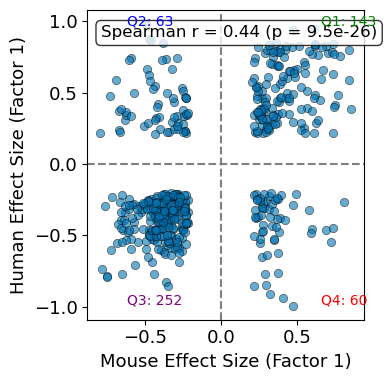

In [52]:
# Step 1: Ensure conserved_df has unique junction pairs (i.e., 1:1 map)
conserved_1to1_df = conserved_df.drop_duplicates(subset=["source_junction", "target_junction"])

# Step 2: Merge mouse and human effect sizes using this 1:1 mapping
# Assume both conserved DataFrames have 'junction_id' and 'effect_size' columns

mouse_df = mouse_ds_factor2_conserved[["junction_id", "effect_size"]].rename(
    columns={"junction_id": "source_junction", "effect_size": "mouse_effect_size"}
)
human_df = human_ds_factor2_conserved[["junction_id", "effect_size"]].rename(
    columns={"junction_id": "target_junction", "effect_size": "human_effect_size"}
)

# Step 3: Join everything
merged_df = conserved_1to1_df[["source_junction", "target_junction"]].merge(
    mouse_df, on="source_junction", how="inner"
).merge(
    human_df, on="target_junction", how="inner"
)

# Step 4: Plot
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1–3 assumed done, so merged_df is available

# Compute correlation
corr, pval = spearmanr(merged_df["mouse_effect_size"], merged_df["human_effect_size"])
corr_text = f"Spearman r = {corr:.2f} (p = {pval:.1e})"

# Compute quadrant counts
q1 = ((merged_df["mouse_effect_size"] > 0) & (merged_df["human_effect_size"] > 0)).sum()
q2 = ((merged_df["mouse_effect_size"] < 0) & (merged_df["human_effect_size"] > 0)).sum()
q3 = ((merged_df["mouse_effect_size"] < 0) & (merged_df["human_effect_size"] < 0)).sum()
q4 = ((merged_df["mouse_effect_size"] > 0) & (merged_df["human_effect_size"] < 0)).sum()

# Plot
plt.figure(figsize=(4, 4))
sns.scatterplot(
    data=merged_df,
    x="mouse_effect_size",
    y="human_effect_size",
    alpha=0.6,
    edgecolor="k"
)

# Axes lines
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

# Labels
plt.xlabel("Mouse Effect Size (Factor 1)")
plt.ylabel("Human Effect Size (Factor 1)")

# Correlation annotation
plt.text(0.05, 0.95, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Quadrant annotations
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Adjust slightly for spacing
plt.text(xlim[1]*0.7, ylim[1]*0.9, f"Q1: {q1}", fontsize=10, color="green")
plt.text(xlim[0]*0.7, ylim[1]*0.9, f"Q2: {q2}", fontsize=10, color="blue")
plt.text(xlim[0]*0.7, ylim[0]*0.9, f"Q3: {q3}", fontsize=10, color="purple")
plt.text(xlim[1]*0.7, ylim[0]*0.9, f"Q4: {q4}", fontsize=10, color="red")
plt.tight_layout()
# Save the plot to pdf 
plt.savefig(os.path.join(paths['figures'], "factor1_human_conserved_junction_effect_sizes.pdf"), dpi=300)
print(os.path.join(paths['figures'], "factor1_human_conserved_junction_effect_sizes.pdf"))
plt.show()

In [49]:
def visualize_junction_by_id(source_junction, validation_results, mouse_atse_df, human_atse_df,
                              db_mouse, db_human, output_dir):
    """
    Visualize a conserved junction pair using a specific mouse junction_id.
    """
    import os

    # Filter validation_results for the matching mouse junction
    matched = validation_results[validation_results["source_junction"] == source_junction]

    if matched.empty:
        print(f"No matching conserved junction found for mouse junction: {source_junction}")
        return None

    # Take highest similarity match if multiple
    junction_data = matched.sort_values(by="average_similarity", ascending=False).iloc[0]

    print("Matched Junction:")
    print(f"  Mouse: {junction_data['source_junction']}")
    print(f"  Human: {junction_data['target_junction']}")
    print(f"  Similarity: {junction_data['average_similarity']:.3f}")

    # Find ATSE events
    mouse_event = find_atse_for_junction(junction_data['source_junction'], mouse_atse_df)
    human_event = find_atse_for_junction(junction_data['target_junction'], human_atse_df)

    # Create output directory
    output_subdir = os.path.join(output_dir, f"junction_{junction_data['source_junction'].replace(':', '_')}")
    os.makedirs(output_subdir, exist_ok=True)

    # Visualize mouse ATSE
    if mouse_event:
        print(f"Visualizing mouse ATSE: {mouse_event}")
        visualize_atse_event(mouse_event, mouse_atse_df, db_mouse,
                             species="mouse", output_dir=output_subdir,
                             padding=5000, show_junc_lines=True)
    else:
        print("No matching mouse ATSE event found.")

    # Visualize human ATSE
    if human_event:
        print(f"Visualizing human ATSE: {human_event}")
        visualize_atse_event(human_event, human_atse_df, db_human,
                             species="human", output_dir=output_subdir,
                             padding=5000, show_junc_lines=True)
    else:
        print("No matching human ATSE event found.")

    print(f"ATSE visualization saved: {output_subdir}")
    return output_subdir

In [50]:
merged_df.sort_values(by="mouse_effect_size")

,source_junction,target_junction,mouse_effect_size,human_effect_size
305,chr2_32328047_32333065_-,chr9_128226173_128234020_+,-0.799456,0.213955
403,chr16_85030365_85056323_-,chr21_25982477_26021839_-,-0.782859,-0.737279
157,chr5_24598803_24622523_-,chr7_151245671_151275113_-,-0.762961,-0.291547
29,chr4_9630952_9635900_-,chr8_61676319_61680967_-,-0.752106,-0.788427
208,chr13_20473287_20564423_+,chr7_36895017_36985922_-,-0.750656,-0.794382
...,...,...,...,...
205,chr4_123361027_123365272_-,chr1_39463686_39468614_+,0.781633,0.753591
404,chr7_135652014_135652089_+,chr10_128047683_128047763_+,0.809774,-0.265829
272,chr11_54482586_54489268_+,chr5_131709272_131716564_-,0.840630,0.590527
180,chr15_73210897_73215978_-,chr8_140668424_140674297_-,0.840649,0.797914


In [ ]:
visualize_junction_pair("chr6_119773901_119779476_-", junction_mapping, mouse_atse, human_atse, db_mouse, db_human, output_dir)

In [ ]:
import anndata as ad
h_splice_adata = ad.read_h5ad("/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-06-11/2025-06-14/param_id_0/data/splice_adata_PHI_psi_var_obs.h5ad")
m_splice_adata = ad.read_h5ad("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-05-13/2025-06-14/param_id_1/data/splice_adata_PHI_psi_var_obs.h5ad")

In [ ]:
X_phi = h_splice_adata.obsm["X_PHI"].astype("float32")
psi_learned = h_splice_adata.varm["psi_learned"].T.astype("float32")
imputed_psi = X_phi @ psi_learned
h_splice_adata.obsm["IMPUTED_PSI"] = imputed_psi

In [ ]:
X_phi = m_splice_adata.obsm["X_PHI"].astype("float32")
psi_learned = m_splice_adata.varm["psi_learned"].T.astype("float32")
imputed_psi = X_phi @ psi_learned
m_splice_adata.obsm["IMPUTED_PSI"] = imputed_psi

In [ ]:
import pandas as pd
from scipy.stats import spearmanr

# Choose a junction of interest from merged_df (e.g., first row)
junction_id = merged_df["target_junction"].iloc[0]
junc_idx = h_splice_adata.var[h_splice_adata.var["junction_id"] == junction_id]["junction_id_index"].values[0]

# Extract imputed PSI vector for this junction (across all cells)
imputed_psi = h_splice_adata.obsm["IMPUTED_PSI"][:, junc_idx]

# Extract age
age_numeric = h_splice_adata.obs["age_numeric"].values

# Compute correlation
corr, pval = spearmanr(age_numeric, imputed_psi)
print(f"Spearman r = {corr:.3f} (p = {pval:.1e})")

# Do the same for mouse 
junction_id = merged_df["source_junction"].iloc[0]
junc_idx = m_splice_adata.var[m_splice_adata.var["junction_id"] == junction_id]["junction_id_index"].values[0]
imputed_psi = m_splice_adata.obsm["IMPUTED_PSI"][:, junc_idx]
age_numeric = m_splice_adata.obs["age_numeric"].values
corr, pval = spearmanr(age_numeric, imputed_psi)
print(f"Spearman r = {corr:.3f} (p = {pval:.1e})")

In [ ]:
import pandas as pd
from scipy.stats import spearmanr

results = []

for _, row in merged_df.iterrows():
    try:
        # Human
        h_junc = row["target_junction"]
        h_idx = h_splice_adata.var[h_splice_adata.var["junction_id"] == h_junc]["junction_id_index"].values[0]
        h_psi = h_splice_adata.obsm["IMPUTED_PSI"][:, h_idx]
        h_age = h_splice_adata.obs["age_numeric"].values
        h_corr, h_pval = spearmanr(h_age, h_psi)

        # Mouse
        m_junc = row["source_junction"]
        m_idx = m_splice_adata.var[m_splice_adata.var["junction_id"] == m_junc]["junction_id_index"].values[0]
        m_psi = m_splice_adata.obsm["IMPUTED_PSI"][:, m_idx]
        m_age = m_splice_adata.obs["age_numeric"].values
        m_corr, m_pval = spearmanr(m_age, m_psi)

        # Save
        results.append({
            "mouse_junction": m_junc,
            "human_junction": h_junc,
            "mouse_corr": m_corr,
            "mouse_pval": m_pval,
            "human_corr": h_corr,
            "human_pval": h_pval
        })

    except Exception as e:
        print(f"Skipping pair due to error: {e}")
        continue

# Convert to DataFrame
corr_df = pd.DataFrame(results)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import os

# Step: correlation_df should already be created like:
# columns = ["mouse_junction", "human_junction", "mouse_corr", "mouse_pval", "human_corr", "human_pval"]

# Compute overall Spearman correlation between the correlation values
corr, pval = spearmanr(corr_df["mouse_corr"], corr_df["human_corr"])
corr_text = f"Spearman r = {corr:.2f} (p = {pval:.1e})"

# Compute quadrant counts
q1 = ((corr_df["mouse_corr"] > 0) & (corr_df["human_corr"] > 0)).sum()
q2 = ((corr_df["mouse_corr"] < 0) & (corr_df["human_corr"] > 0)).sum()
q3 = ((corr_df["mouse_corr"] < 0) & (corr_df["human_corr"] < 0)).sum()
q4 = ((corr_df["mouse_corr"] > 0) & (corr_df["human_corr"] < 0)).sum()

# Plot
plt.figure(figsize=(4, 4))
sns.scatterplot(
    data=corr_df,
    x="mouse_corr",
    y="human_corr",
    alpha=0.6,
    edgecolor="k"
)

# Axes lines
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

# Labels
plt.xlabel("Mouse PSI~Age (Spearman r)")
plt.ylabel("Human PSI~Age (Spearman r)")

# Correlation annotation
plt.text(0.05, 0.95, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Quadrant annotations
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

plt.text(xlim[1]*0.7, ylim[1]*0.9, f"Q1: {q1}", fontsize=10, color="green")
plt.text(xlim[0]*0.7, ylim[1]*0.9, f"Q2: {q2}", fontsize=10, color="blue")
plt.text(xlim[0]*0.7, ylim[0]*0.9, f"Q3: {q3}", fontsize=10, color="purple")
plt.text(xlim[1]*0.7, ylim[0]*0.9, f"Q4: {q4}", fontsize=10, color="red")

plt.tight_layout()

# Optional: Save as PDF
# paths['figures'] must be defined beforehand
plt.savefig(os.path.join(paths['figures'], "psi_age_corr_mouse_vs_human.pdf"), dpi=300)

plt.show()


In [ ]:
h_splice_adata.var

In [ ]:
import numpy as np

def make_psi_pair_df(h_junc, m_junc):
    # Human
    h_idx = h_splice_adata.var[h_splice_adata.var["junction_id"] == h_junc]["junction_id_index"].values[0]
    h_psi = h_splice_adata.obsm["IMPUTED_PSI"][:, h_idx]
    h_age = pd.Categorical(h_splice_adata.obs["age_group"], categories=["young", "old"], ordered=True)
    h_gene = h_splice_adata.var[h_splice_adata.var["junction_id"] == h_junc]["gene_name"].values[0]

    # Mouse
    m_idx = m_splice_adata.var[m_splice_adata.var["junction_id"] == m_junc]["junction_id_index"].values[0]
    m_psi = m_splice_adata.obsm["IMPUTED_PSI"][:, m_idx]
    m_age = pd.Categorical(m_splice_adata.obs["age_group"], categories=["young", "old"], ordered=True)

    pair_label = f"{h_junc} ⇄ {m_junc}"

    h_df = pd.DataFrame({"PSI": h_psi, "AgeGroup": h_age, "Species": "Human", "Pair": pair_label, "Gene": h_gene})
    m_df = pd.DataFrame({"PSI": m_psi, "AgeGroup": m_age, "Species": "Mouse", "Pair": pair_label, "Gene": h_gene})

    return pd.concat([h_df, m_df], axis=0)

# --- Select ATSE event ---
event_id = h_splice_adata.var[h_splice_adata.var["junction_id"] == human_junction]["event_id"].values[0]
human_junctions = h_splice_adata.var[h_splice_adata.var["event_id"] == event_id]["junction_id"].values
mouse_junctions = merged_df[merged_df["target_junction"].isin(human_junctions)]["source_junction"].values

# --- Build combined dataframe ---
plot_pairs = []
for h_junc in human_junctions:
    if h_junc in merged_df["target_junction"].values:
        m_junc = merged_df[merged_df["target_junction"] == h_junc]["source_junction"].values[0]
        try:
            plot_pairs.append(make_psi_pair_df(h_junc, m_junc))
        except Exception as e:
            print(f"Skipping {h_junc} ↔ {m_junc}: {e}")

psi_plot_df = pd.concat(plot_pairs, axis=0)

In [ ]:
psi_plot_df

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set publication-style aesthetics
sns.set(style="whitegrid", font_scale=1.2, rc={
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11
})

# Custom palette for clarity
palette = {"Human": "#1f77b4", "Mouse": "#ff7f0e"}

# Plot base violins
g = sns.catplot(
    data=psi_plot_df,
    kind="violin",
    x="AgeGroup", y="PSI", hue="Species",
    col="Pair", col_wrap=1,
    split=True, inner=None, palette=palette,
    height=3.5, aspect=1.1, linewidth=1
)

# Overlay median points
for ax, pair_id in zip(g.axes.flatten(), psi_plot_df["Pair"].unique()):
    for species in ["Human", "Mouse"]:
        for age in ["young", "old"]:
            subset = psi_plot_df[
                (psi_plot_df["Pair"] == pair_id) &
                (psi_plot_df["Species"] == species) &
                (psi_plot_df["AgeGroup"] == age)
            ]
            if not subset.empty:
                x = 0 if age == "young" else 1
                shift = -0.12 if species == "Human" else 0.12
                median_val = subset["PSI"].median()
                ax.scatter(x + shift, median_val, color="black", s=30, zorder=10, marker='o', edgecolor='white', linewidth=0.5)

# Final labels
gene_name = psi_plot_df["Gene"].unique()[0]
g.set_titles(col_template="{col_name}", size=11)
g.set_axis_labels("Age Group", "Imputed PSI")
g.add_legend(title="Species", loc="upper right", frameon=False)

# Suptitle with adjusted padding
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle(f"Conserved Junctions in ATSE Event ({gene_name})", fontsize=13)

# Tight layout + export
plt.tight_layout()
output_path = os.path.join(paths["figures"], f"psi_age_conserved_{gene_name}.pdf")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
